# Set-up

## Load libraires

In [ ]:
directory="C:/Users/atanoh/Documents/2025/stage/C03_Torres_2005/CAP"
setwd(directory)
#Install and load libraires
source("./src/libraries.r")

Warning message:
"le package 'reshape2' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"

Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"le package 'DescTools' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'mice' a été compilé avec la version R 4.2.3"
Warning message in check_dep_version():
"ABI version mismatch: 
lme4 was built with Matrix ABI version 1
Current Matrix ABI version is 0
Please re-install lme4 from source or restore original 'Matrix' package"

Attachement du package : 'mice'


L'objet suivant est masqué depuis 'package:stats':

    filter


Les objets suivants sont masqués depuis 'package:base':

    cbind, rbind


Warning message:


In [126]:
# Functions
invisible(lapply(list.files("./src/descriptive_stats", full.names = TRUE), source))
invisible(lapply(list.files("./src/models", full.names = TRUE), source))

Warning message in .checkFieldsInMethod(def, fieldNames, allMethods):
"affectation non-locale à des noms qui ne sont pas des champs (coquille possible ?)
    imp <<- dataset
(dans la méthode "initialize" de la classe "logit")"
Warning message in .checkFieldsInMethod(def, fieldNames, allMethods):
"affectation non-locale à des noms qui ne sont pas des champs (coquille possible ?)
    imp_data <<- dataset
(dans la méthode "initialize" de la classe "cox")"


## Load dataset

In [3]:
data <- read_sav("./Torres_bd_vf.sav")
data <- data %>%
  mutate(across(where(~ inherits(.x, "haven_labelled")), ~ as.factor(.x)))

# Data exploration

## Load and treat dataset

In [4]:
#Characteristics of dataset
torres_caracs=characteristics(data[, !sapply(data, inherits, what = "Date")])
#Correction
data[["daysinICU"]]=as.numeric(data$EvolUCIFechaAlta-data$EvolUCIFechaIngr)+1
check_dias_uci <- with(data, 
  ((is.na(EvolDiasUCI)| EvolDiasUCI==0) & is.na(EvolUCIFechaAlta) & is.na(EvolUCIFechaIngr)) |
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr)+1)|
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr))
)
# EvolDiasUCI vs EvolIUCI 
check_iuci <- with(data,
  EvolUCI == 0 | !is.na(EvolDiasUCI)
)
invalid <- which(!check_dias_uci %in% TRUE)  # selects only FALSE (excludes NA)
data$EvolDiasUCI[invalid] <- data$daysinICU[invalid]
data[!check_dias_uci,c("EvolDiasUCI","daysinICU","EvolUCIFechaIngr","EvolUCIFechaAlta")]
#Create variables
#Year of admission
data$YearOfAdmission <- as.factor(format(as.Date(data$FechaIngr), "%Y"))
#Ratio Pao2/FiO2
data$RatioPao2_oxygen <- data$GpO201/(data$GFiO201/100)
#Macrolide therapy
abx_vars <- paste0("TAntibiotico", 1:12)
macrolides <- c("azitromicina", "claritromicina", "eritromicina")
data$macrolide <- factor(
  apply(data[abx_vars], 1, function(row) any(row %in% macrolides, na.rm = TRUE)),
  levels = c(FALSE, TRUE),
  labels = c(0, 1)
)
data <- data %>%
  mutate(TimeToFirstAntibiotic_SS = case_when(
    TTiempoDesdeLlegUCIAS <= 1 & CdxShockSept == 1 ~ "0",
    TTiempoDesdeLlegUCIAS <= 4 & CdxShockSept == 0 ~ "1",
    TRUE ~ NA_character_  # For all other cases
  )) %>%
  mutate(TimeToFirstAntibiotic_SS = as.factor(TimeToFirstAntibiotic_SS))
  #Oder by patient ids
data <- data[order(data$IdPac), ]

#Select variables of interest
vars_dint <- c("IdPac","YearOfAdmission","Edad",
"Sexo",
"Fumador",
"Diabetes",
"EPOC",
"HTA",
"Cancer",
"CardIsq",
"CFiebre",
"CAlterNivelConc",
"CDisnea",
"CTos",
"CEscalofrios",
"CDolorPleur",
"FINE",
"Puntos",
"CdxVM",
"CdxVMtipo",
"CdxShockSept",
"CdxPAP90",
"CdxMultilobar",
"CdxPaFi250",
"RatioPao2_oxygen",
"UCI_Interm",
"TimeToFirstAntibiotic_SS",
"macrolide",
"BGlucosa",
"BCreatinina",
"HPlaquetas",
"HLeucocitos",
"BProteinasTot",
"PCT1",
"IL61",
"IL81",
"IL101",
"Temperatura",
"FR",
"FC",
"EarlyFailure",
"EMV",
"ESS",
"ED",
"LateFailure",
"RP",
"RF",
"LMV",
"LSS",
"tiempo_estancia",
"EvolDiasUCI",
"EvolMort28",
"EstabClin",
"Dia_TF",
"Grupo",
"ITT",
"PP",
"Centro"
)


EvolDiasUCI,daysinICU,EvolUCIFechaIngr,EvolUCIFechaAlta
<dbl>,<dbl>,<date>,<date>
11,11,2004-09-10,2004-09-20
5,5,2004-12-07,2004-12-11
35,35,2005-03-15,2005-04-18
NA,NA,NA,NA
16,16,2006-03-28,2006-04-12
63,63,2006-04-20,2006-06-21
9,9,2006-12-28,2007-01-05
10,10,2007-03-07,2007-03-16
10,10,2007-10-23,2007-11-01


In [5]:
#Convert data type
data_dint<-data[,vars_dint] %>%
  mutate(FINE=as.factor(FINE))%>%
  mutate(BProteinasTot =as.numeric(as.character(BProteinasTot)))%>%
  mutate(PCT1 =as.numeric(as.character(PCT1 )))%>%
  mutate(IL61 =as.numeric(as.character(IL61 )))%>%
  mutate(IL81 =as.numeric(as.character(IL81 )))%>%
  mutate(IL101 =as.numeric(as.character(IL101)))
data_dint[["ratio_il6_il10"]]=data_dint$IL101/data_dint$IL61
#Manually builds early and late failure
data_dint$EarlyFailureMan <- with(data_dint, factor(as.integer(EMV == 1 | ESS == 1 | ED == 1), levels = c(0,1)))
data_dint$LateFailureMan <- with(data_dint, factor(as.integer(LMV == 1 | LSS == 1 | RP == 1 | RF == 1), levels = c(0,1)))
data_dint$TreatmentFailureMan <- with(data_dint, factor(as.integer(EarlyFailureMan == 1 | LateFailureMan == 1), levels = c(0,1)))
# #Suppress
#data_dint <- data_dint %>% select(-TreatmentFailure, -LateFailure, -EarlyFailure)
#Compute pleural effusion
data$pleural_effusion <- with(data, factor(as.integer(!is.na(LPGlu) | !is.na(LPProt)| !is.na(LPLDH)| 
!is.na(LPCelulas)| !is.na(LPPM)), levels = c(0,1))) 
# table(data$Cancer,data$Grupo) 
caracs_dint<-characteristics(data_dint)
caracs_dint

variable,types,nombre_de_modalites,number_of_missing_values,proportion_missing_values_percent,moyenne,maximum,minimum,mode,proportion_mode_percent
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
IdPac,numeric,95,0,0.0,47.633333,301.0000,1.0,20,1.667
YearOfAdmission,factor,9,0,0.0,NA,NA,NA,2,0.000
Edad,numeric,59,0,0.0,65.241667,96.0000,19.0,81,7.500
Sexo,factor,2,0,0.0,NA,NA,NA,2,0.000
Fumador,factor,3,0,0.0,NA,NA,NA,3,0.000
Diabetes,factor,2,0,0.0,NA,NA,NA,1,19.167
EPOC,factor,2,0,0.0,NA,NA,NA,1,15.833
HTA,factor,2,0,0.0,NA,NA,NA,1,38.333
Cancer,factor,2,0,0.0,NA,NA,NA,1,9.167


Missing informations for temperature, respiratory and heart rates mostly

,IdPac,YearOfAdmission,Edad,Sexo,Fumador,Diabetes,EPOC,HTA,Cancer,CardIsq,⋯,IL81,EstabClin,EvolDiasUCI,FC,FR,Temperatura,TimeToFirstAntibiotic_SS,BProteinasTot,Dia_TF,
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,0
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,0,1
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,1,1
20,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,0,2
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,1,0,2
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,1,2
14,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,0,3
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,0,1,0,0,3
2,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,1,0,1,4
5,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,0,0,0,6


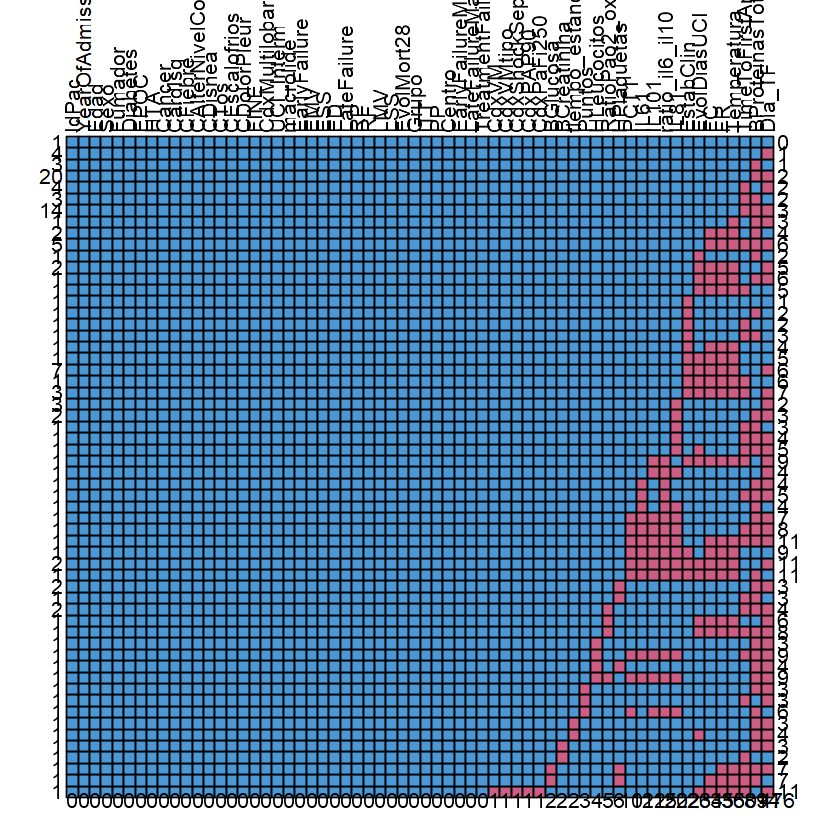

In [6]:
md.pattern(data_dint, rotate.names = TRUE)

Let's suppose MAR

## Intention to treat

### Descriptive statistics

In [7]:
#Test normality of numerical variables
normality <- sapply(data_dint[!names(data_dint) %in% "IdPac"],seek_normality)
data.frame(variable = names(normality), normality = normality)

,variable,normality
,<chr>,<chr>
YearOfAdmission,YearOfAdmission,NA
Edad,Edad,not normal
Sexo,Sexo,NA
Fumador,Fumador,NA
Diabetes,Diabetes,NA
EPOC,EPOC,NA
HTA,HTA,NA
Cancer,Cancer,NA
CardIsq,CardIsq,NA


In [8]:
#Explicit modalities of categorical variables
data_dint_explcit<-data_dint %>%
  mutate(Sexo = recode(Sexo, "1" = "Male", "0" = "Female")) %>%
  mutate(Diabetes = recode(Diabetes, "1" = "Diabetes mellitus", "0" = "Not diabetic"))%>%
  mutate(Fumador = recode(Fumador, "1" = "Current smoker", "0" = "Not smoker"))%>%
  mutate(EPOC = recode(EPOC, "1" = "Chronic pulmonary disease", "0" = "Not EPOC"))%>%
  mutate(HTA = recode(HTA, "1" = "Congestive heart failure", "0" = "Not HTA"))%>%
  mutate(Cancer = recode(Cancer, "1" = "History of malignancy", "0" = "No cancer"))%>%
  mutate(CardIsq = recode(CardIsq, "1" = "Ischemic heart disease", "0" = "No IHD"))%>%
  mutate(CFiebre = recode(CFiebre, "1" = "Fever", "0" = "No fever"))%>%
  mutate(CAlterNivelConc = recode(CAlterNivelConc, "1" = "Altered Mental status", "0" = "Not altered"))%>%
  mutate(CDisnea = recode(CDisnea, "1" = "Breathlessness", "0" = "No Breathlessness"))%>%
  mutate(CTos = recode(CTos, "1" = "Cough", "0" = "No cough"))%>%
  mutate(CEscalofrios = recode(CEscalofrios, "1" = "Chills", "0" = "No chills"))%>%
  mutate(CDolorPleur = recode(CDolorPleur, "1" = "Chest pain", "0" = "No chest pain"))%>%
  mutate(CdxVM = recode(CdxVM, "1" = "Mechanical ventialtion", "0" = "No MV"))%>%
  mutate(CdxVMtipo = recode(CdxVMtipo, "1" = "Noninvasive alone","2" = "Noninvasive followed by invasive","3" = "Invasive alone", "0" = "No MV"))%>%
  mutate(CdxShockSept = recode(CdxShockSept, "1" = "Septic shock", "0" = "No shock"))%>%
  mutate(CdxPAP90 = recode(CdxPAP90, "1" = "Systolic blood pressure< 90 mmHg", "0" = "PAP>90"))%>%
  mutate(CdxMultilobar = recode(CdxMultilobar, "1" = "Multilobar involvement", "0" = "No involvement"))%>%
  mutate(CdxPaFi250 = recode(CdxPaFi250, "1" = "Ratio of PaO2 to fraction of inspired oxygen < 250 mmHg", "0" = "Ratio>250"))%>%
  mutate(UCI_Interm = recode(UCI_Interm, "1" = "ICU admission", "0" = "No ICU admission"))%>%
  mutate(TimeToFirstAntibiotic_SS = recode(TimeToFirstAntibiotic_SS, "1" = "Within 1h in patients with septic shock", "0" = "Within 4h in patients without septic shock"))%>% 
  mutate(macrolide = recode(macrolide, "1" = " Macrolide combination therapy", "0" = "No macrolide"))%>%
  mutate(EarlyFailureMan = recode(EarlyFailureMan, "1" = "Early failure", "0" = "No early failure"))%>%
  mutate(EMV = recode(EMV, "1" = "Early mechanical ventilation", "0" = "EVM"))%>%
  mutate(ESS = recode(ESS, "1" = "Early septic shock", "0" = "no ESS"))%>%
  mutate(ED = recode(ED, "1" = "Early death", "0" = "no ED"))%>%
  mutate(LateFailureMan = recode(LateFailureMan, "1" = "Late failure", "0" = "No late failure"))%>%
  mutate(RP = recode(RP, "1" = "Radiographic progression", "0" = "no RP"))%>%
  mutate(RF = recode(RF, "1" = "Respiratory failure", "0" = "no RF"))%>%
  mutate(LMV = recode(LMV, "1" = "Late mechanical ventilation", "0" = "no LMV"))%>%
  mutate(LSS = recode(LSS, "1" = "Late septic shock", "0" = "no LSS"))%>%
  mutate(EvolMort28 = recode(EvolMort28, "1" = "In-hospitality mortality", "0" = "no IHM"))%>%
  mutate(TreatmentFailureMan = recode(TreatmentFailureMan, "1" = "Treatment failure", "0" = "No treatment failure"))
#Summary of categorical variables
summary_cat_by_group(data_dint_explcit, "Grupo")

Variable,Category,Overall_N_prop,0_N_prop,1_N_prop
<chr>,<chr>,<chr>,<chr>,<chr>
YearOfAdmission,2004,8 (6.7%),5 (8.5%),3 (4.9%)
YearOfAdmission,2005,24 (20%),13 (22%),11 (18%)
YearOfAdmission,2006,21 (17.5%),8 (13.6%),13 (21.3%)
YearOfAdmission,2007,17 (14.2%),7 (11.9%),10 (16.4%)
YearOfAdmission,2008,14 (11.7%),7 (11.9%),7 (11.5%)
YearOfAdmission,2009,9 (7.5%),6 (10.2%),3 (4.9%)
YearOfAdmission,2010,13 (10.8%),7 (11.9%),6 (9.8%)
YearOfAdmission,2011,12 (10%),5 (8.5%),7 (11.5%)
YearOfAdmission,2012,2 (1.7%),1 (1.7%),1 (1.6%)


In [9]:
# Summary of numerical variables 
summary_num_by_group(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Variable,Overall_mean_SD,Overall_med_IQR,Overall_min_max,0_mean_SD,0_med_IQR,0_min_max,1_mean_SD,1_med_IQR,1_min_max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Edad,65.2 (19.6),69.5 (53.0 - 81.0),19.0 - 96.0,66.1 (20.1),70.0 (54.5 - 81.0),19.0 - 96.0,64.5 (19.1),69.0 (53.0 - 81.0),24.0 - 89.0
Puntos,108.6 (36.4),110.0 (86.0 - 135.0),4.0 - 212.0,110.2 (34.6),111.0 (91.0 - 135.0),4.0 - 173.0,107.1 (38.2),109.0 (85.8 - 134.2),28.0 - 212.0
RatioPao2_oxygen,232.9 (78.7),238.1 (179.6 - 270.5),63.6 - 609.5,229.6 (82.9),228.6 (170.5 - 287.6),76.0 - 407.5,236.2 (74.9),239.0 (210.1 - 265.6),63.6 - 609.5
BGlucosa,149.5 (72.4),130.5 (106.0 - 167.2),50.0 - 548.0,150.8 (65.6),129.0 (107.0 - 180.0),50.0 - 394.8,148.3 (78.9),131.0 (106.0 - 159.0),64.0 - 548.0
BCreatinina,1.6 (0.9),1.3 (1.0 - 1.8),0.4 - 5.2,1.6 (1.0),1.3 (1.0 - 1.8),0.4 - 5.2,1.5 (0.9),1.3 (0.9 - 1.8),0.6 - 4.9
HPlaquetas,248.0 (131.7),214.5 (175.2 - 283.0),32.0 - 864.0,260.4 (150.8),217.0 (175.0 - 283.0),81.0 - 864.0,235.7 (109.3),214.0 (176.0 - 282.0),32.0 - 630.0
HLeucocitos,15.1 (10.7),13.4 (9.0 - 19.7),0.7 - 74.0,14.9 (9.0),14.4 (9.2 - 23.0),0.7 - 36.7,15.3 (12.2),12.6 (9.0 - 16.7),1.3 - 74.0
BProteinasTot,27.8 (24.8),8.2 (6.6 - 56.5),4.9 - 69.0,23.4 (23.0),7.5 (6.8 - 47.0),5.2 - 58.0,31.2 (26.1),19.6 (6.3 - 57.5),4.9 - 69.0
PCT1,6.3 (11.8),1.8 (0.5 - 7.2),0.0 - 86.3,6.7 (8.6),3.1 (0.8 - 9.5),0.1 - 37.4,6.0 (14.2),1.2 (0.4 - 4.4),0.0 - 86.3


### Comparison tests

In [10]:
compare_var_cat(data_dint[!names(data_dint) %in% "IdPac"],"Grupo")

Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingenc

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
YearOfAdmission,Fisher,0.886,No significative difference
Sexo,Chi2,0.427,No significative difference
Fumador,Chi2,0.872,No significative difference
Diabetes,Chi2,0.580,No significative difference
EPOC,Chi2,0.280,No significative difference
HTA,Chi2,0.740,No significative difference
Cancer,Chi2,0.186,No significative difference
CardIsq,Chi2,0.692,No significative difference
CFiebre,Chi2,0.346,No significative difference


In [11]:
#Double check for septic shock
contingency <- table(data_dint$CdxShockSept, data_dint$Grupo)
print(chisq.test(contingency)$p.value)
print(fisher.test(contingency)$p.value)
# if (pval < 0.1) "associated/significative difference" else "No significative difference"

[1] 0.1178949
[1] 0.08699988


Associated/significatve difference for the the fisher test

In [12]:
compare_var_num(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"


Variable,test,pvalue,verdict
<chr>,<chr>,<dbl>,<chr>
Edad,Mann-Whitney,0.592,No significative difference
Puntos,Student,0.652,No significative difference
RatioPao2_oxygen,Mann-Whitney,0.695,No significative difference
BGlucosa,Mann-Whitney,0.620,No significative difference
BCreatinina,Mann-Whitney,0.607,No significative difference
HPlaquetas,Mann-Whitney,0.792,No significative difference
HLeucocitos,Mann-Whitney,0.485,No significative difference
BProteinasTot,Mann-Whitney,0.542,No significative difference
PCT1,Mann-Whitney,0.040,associated/significative difference


In [13]:
#Compare proportions
compare_proportions(data_dint[!names(data_dint) %in% "IdPac"], c("TreatmentFailureMan"
                                ,"EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS"),
                                 "Grupo")

Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"


Variable,P_value,Difference_CI
<chr>,<dbl>,<chr>
TreatmentFailureMan,0.02,17 (3–31)
EarlyFailureMan,0.95,0 (-10–11)
EMV,0.69,2 (-8–11)
ESS,0.62,2 (-5–9)
ED,0.97,0 (-6–7)
LateFailureMan,0.00,22 (11–33)
RP,0.01,14 (4–23)
RF,0.09,7 (-1–15)
LMV,0.16,5 (-2–12)


In [14]:
compare_medians(data_dint[!names(data_dint) %in% "IdPac"], c("tiempo_estancia","EstabClin"),"Grupo")

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
tiempo_estancia,0.5,-2.5 – 3.5,0.8311
EstabClin,-1.0,-2 – 1,0.2769


In [15]:
group0 <- data_dint[data_dint[["Grupo"]] == 0 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
group1 <- data_dint[data_dint[["Grupo"]] == 1 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
    
    # Remove NA
group0 <- group0[!is.na(group0)]
group1 <- group1[!is.na(group1)]
if (length(group0) == 0 || length(group1) == 0) return(NULL)

    # Median difference
diff_median <- round(median(group1) - median(group0), 2)
    
    # P-value
p_val <- round(wilcox.test(group0, group1, exact = FALSE)$p.value, 4)
    
    # Bootstrap CI for median difference
boot_diffs <- replicate(1000, {
      med1 <- median(sample(group1, replace = TRUE))
      med0 <- median(sample(group0, replace = TRUE))
      med1 - med0
    })
    
ci <- quantile(boot_diffs, probs = c((1 - 0.95)/2, 1 - (1 - 0.95)/2))
ci_str <- paste0(round(ci[1], 2), " – ", round(ci[2], 2))
    
data.frame(
      Variable = "EvolDiasUCI",
      Median_Diff = diff_median,
      CI_95 = ci_str,
      P_value = p_val,
      stringsAsFactors = FALSE
    )

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
EvolDiasUCI,-1,-3 – 2,0.7017


Significative difference for procalcitonin, IL-10 and septic shock

### Impute missing values

In [16]:
#Prepare variables
## Treatment failure
data_dint$TreatmentFailureMan <- as.numeric(as.character(data_dint$TreatmentFailureMan))
data_dint$Dia_TF[is.na(data_dint$Dia_TF)] <- 5 #Censor at 5 days

##Length of stay in hospital
data_dint$StayHosp <- as.numeric(as.character(ifelse(is.na(data_dint$tiempo_estancia),0,1)))

##Time in ICU
data_dint$EvolDiasUCI[is.na(data_dint$EvolDiasUCI)] <- data$EvolDiasInterm[is.na(data$EvolDiasUCI)]
data_dint$EvolDiasUCI[is.na(data_dint$EvolDiasUCI)] <- data_dint$tiempo_estancia[is.na(data_dint$EvolDiasUCI)]
data_dint$EvolDiasUCI[data_dint$UCI_Interm==0] <- 0
data_dint$EvolDiasUCI_tronq<-data_dint$EvolDiasUCI
data_dint$EvolDiasUCI_tronq[data_dint$UCI_Interm==1]<-ifelse(data_dint$EvolDiasUCI[data_dint$UCI_Interm==1]>28 | data_dint$EvolMort28[data_dint$UCI_Interm==1]==1,28,data_dint$EvolDiasUCI[data_dint$UCI_Interm==1]) #truncate at 28 days
data_dint$UCI_event<- as.numeric(as.character(ifelse(is.na(data$EvolUCIFechaAlta) | is.na(data$EvolIntermFechaAlta),0,1)))

## Clinical stability
data_dint$EstabClin_event <- as.numeric(as.character(ifelse(is.na(data_dint$EstabClin),0,1)))
data_dint$EstabClin[is.na(data_dint$EstabClin)] <- data_dint$tiempo_estancia[is.na(data_dint$EstabClin)]

In [17]:
#Imputation
vars_to_impute<-caracs_dint[caracs_dint$number_of_missing_values>0,"variable"]
print(caracs_dint[caracs_dint$number_of_missing_values>0,"variable"])

 [1] "Puntos"                   "CdxVM"                   
 [3] "CdxVMtipo"                "CdxShockSept"            
 [5] "CdxPAP90"                 "CdxPaFi250"              
 [7] "RatioPao2_oxygen"         "TimeToFirstAntibiotic_SS"
 [9] "BGlucosa"                 "BCreatinina"             
[11] "HPlaquetas"               "HLeucocitos"             
[13] "BProteinasTot"            "PCT1"                    
[15] "IL61"                     "IL81"                    
[17] "IL101"                    "Temperatura"             
[19] "FR"                       "FC"                      
[21] "tiempo_estancia"          "EvolDiasUCI"             
[23] "EstabClin"                "Dia_TF"                  
[25] "ratio_il6_il10"          


In [18]:
# List of all column names
all_vars <- names(data_dint[!names(data_dint) %in% "IdPac"])

# Create a method vector with empty strings
meth <- rep("", length(all_vars))
names(meth) <- all_vars

# Set "pmm" only for the 3 target columns
meth[c("PCT1", "IL101","CdxShockSept")] <- "pmm"

# Run mice with the method vector
imp <- mice(data_dint[!names(data_dint) %in% "IdPac"], m = 5, method = meth, seed = 123)


 iter imp variable
  1   1  CdxShockSept  PCT1  IL101
  1   2  CdxShockSept  PCT1  IL101
  1   3  CdxShockSept  PCT1  IL101
  1   4  CdxShockSept  PCT1  IL101
  1   5  CdxShockSept  PCT1  IL101
  2   1  CdxShockSept  PCT1  IL101
  2   2  CdxShockSept  PCT1  IL101
  2   3  CdxShockSept  PCT1  IL101
  2   4  CdxShockSept  PCT1  IL101
  2   5  CdxShockSept  PCT1  IL101
  3   1  CdxShockSept  PCT1  IL101
  3   2  CdxShockSept  PCT1  IL101
  3   3  CdxShockSept  PCT1  IL101
  3   4  CdxShockSept  PCT1  IL101
  3   5  CdxShockSept  PCT1  IL101
  4   1  CdxShockSept  PCT1  IL101
  4   2  CdxShockSept  PCT1  IL101
  4   3  CdxShockSept  PCT1  IL101
  4   4  CdxShockSept  PCT1  IL101
  4   5  CdxShockSept  PCT1  IL101
  5   1  CdxShockSept  PCT1  IL101
  5   2  CdxShockSept  PCT1  IL101
  5   3  CdxShockSept  PCT1  IL101
  5   4  CdxShockSept  PCT1  IL101
  5   5  CdxShockSept  PCT1  IL101


Warning message:
"Number of logged events: 4"


### Logistic regression

In [19]:
# Variables to explain
vars_to_explain <- c("TreatmentFailureMan",
                     "EarlyFailureMan","EMV","ESS","ED",
                     "LateFailureMan","RP","RF","LMV","LSS","EvolMort28")

In [101]:
#initialize model
model_logit=logit(imp,vars_to_explain)
#Fitting model
main_var<-"Grupo"
other_variables<-c("IL101","PCT1","CdxShockSept","Centro","YearOfAdmission")
model_logit$fit_logit(main_var=main_var, other_variables=other_variables, interraction_terms = c("Sexo"))

Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
War

Variable_to_explain,OR_CI_not_adjusted,p_value_1,OR_CI_adjusted,p_value_2
<chr>,<chr>,<dbl>,<chr>,<dbl>
TreatmentFailureMan x Grupo1,0.3 (0.06 - 1.44),0.1320262,0.13 (0.02 - 0.88),0.0369492
TreatmentFailureMan x Sexo1,0.92 (0.28 - 3.03),0.8856933,NA (NA - NA),NA
TreatmentFailureMan x Grupo1:Sexo1,1.08 (0.15 - 8.01),0.9400994,NA (NA - NA),NA
EarlyFailureMan x Grupo1,0.74 (0.13 - 4.2),0.7309458,0.43 (0.05 - 3.93),0.4529377
EarlyFailureMan x Sexo1,0.47 (0.08 - 2.64),0.3891297,NA (NA - NA),NA
EarlyFailureMan x Grupo1:Sexo1,1.52 (0.14 - 17.15),0.7317853,NA (NA - NA),NA
EMV x Grupo1,0.75 (0.09 - 5.97),0.7840889,0.52 (0.04 - 6.58),0.6088096
EMV x Sexo1,0.75 (0.11 - 5),0.7643626,NA (NA - NA),NA
EMV x Grupo1:Sexo1,0.97 (0.06 - 15.84),0.9826289,NA (NA - NA),NA


In [21]:
#Model performances
model_logit$performance_logit(main_var=main_var, other_variables=other_variables,interraction_terms = c("Sexo"))

Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
Warning message:
"glm.fit: l'algorithme n'a pas convergé"
Warning message:
"glm.fit: des probabilités ont été ajustées numériquement à 0 ou 1"
War

Variable_to_explain,TreatmentFailureMan,EarlyFailureMan,EMV,ESS,ED,LateFailureMan,RP,RF,LMV,LSS,EvolMort28
accuracy,0.8000000,0.9000000,0.9250000,0.9583333,0.9666667,0.8750000,0.9166667,0.9500000,0.9583333,0.9666667,0.8750000
sensitivity,0,0,0,0,0,0,0,0,0,0,0
specificity,1,1,1,1,1,1,1,1,1,1,1
diff_prop_placebo,28.81,10.17,8.47,5.08,3.39,23.73,15.25,8.47,6.78,6.78,15.25
diff_prop_traitement,11.48,9.84,6.56,3.28,3.28,1.64,1.64,1.64,1.64,0.00,9.84
number_deviant_residuals,7,9,9,5,4,1,5,6,5,4,10
accuracy_adjusted,0.7570093,0.8785047,0.9252336,0.9252336,0.9626168,0.8411215,0.9065421,0.9345794,0.9345794,0.9532710,0.8317757
sensitivity_adjusted,0.04347826,0.00000000,0.00000000,0.00000000,0.25000000,0.21428571,0.11111111,0.16666667,0.00000000,0.25000000,0.06666667
specificity_adjusted,0.9523810,0.9791667,1.0000000,0.9705882,0.9902913,0.9354839,0.9795918,0.9801980,0.9803922,0.9805825,0.9565217
diff_prop_placebo_adjusted,26.89,8.25,8.47,5.08,-0.46,17.96,13.33,6.55,6.78,4.86,11.41


### Log-rank test and cox model

       chisq df     p
Grupo   3.24  1 0.072
GLOBAL  3.24  1 0.072


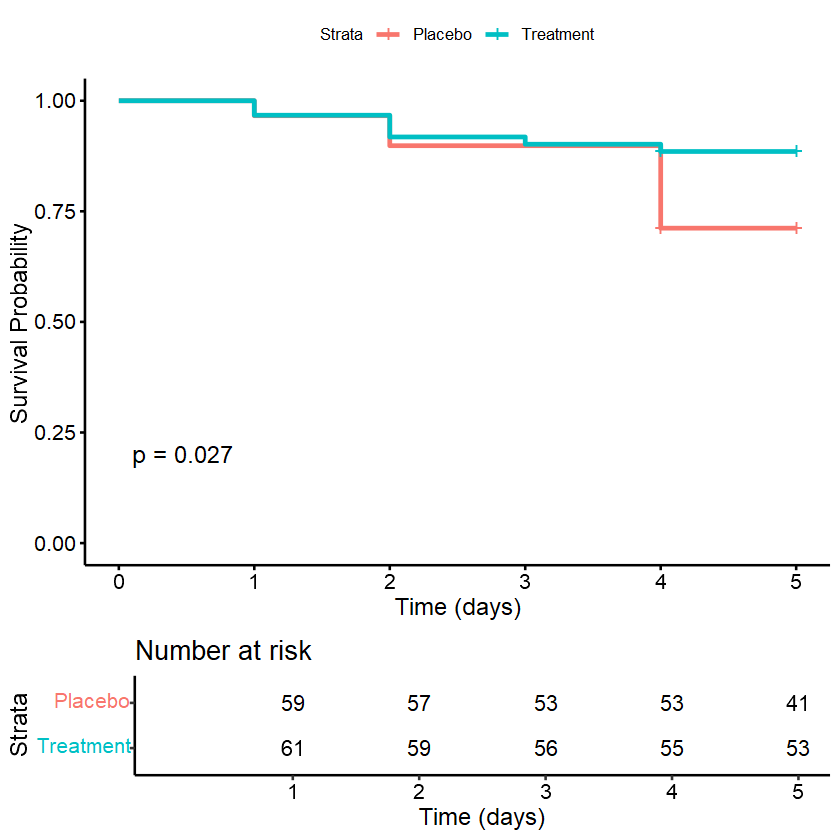

In [22]:
# Proportional hazard test for our variables of interest
surv_TF<-Surv(data_dint$Dia_TF, data_dint$TreatmentFailureMan) 
cox_model <- coxph(surv_TF~ Grupo, data= data_dint)

# Test proportional hazards assumption
ph_test <- cox.zph(cox_model)

# Print the results
print(ph_test)

#Log rank test
fit <- survfit(surv_TF ~ Grupo, data = data_dint)
ggsurvplot(fit, data = data_dint, pval = TRUE, conf.int = FALSE,
           risk.table = TRUE, legend.labs = c("Placebo", "Treatment"),
           xlab = "Time (days)", ylab = "Survival Probability")


In [130]:
#Model
vars_to_expl <- list(c("Dia_TF","TreatmentFailureMan"),
                    c("tiempo_estancia","StayHosp"),
                     c("EvolDiasUCI","UCI_event"),
                     c("EstabClin","EstabClin_event"))
cox(imp,vars_to_expl)$get_cox_results(main_var="Centro", other_variables=other_variables)

Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  13 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  13 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  13 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  13 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  13 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
"Loglik converged before variable  1 ; coefficient may be infinite. "
Warning message in coxph.fit(X, Y, istrat, offset, in

Time,Event,HR_CI_not_adjusted,p_value_1,HR_CI_adjusted,p_value_2,ph_test_p_value,ph_test_verdict
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
Dia_TF,TreatmentFailureMan x LA FE,1.25 (0.46 - 3.36),6.443719e-01,1.18 (0.27 - 5.2),0.7928529973,0.720,PH assumption met
Dia_TF,TreatmentFailureMan x SON DURETA,0.55 (0.06 - 4.7),5.682560e-01,0.3 (0.02 - 4.3),0.3172042321,0.720,PH assumption met
tiempo_estancia,StayHosp x LA FE,1.31 (0.82 - 2.07),2.536097e-01,1.42 (0.77 - 2.62),0.2544720173,0.022,PH assumption violated
tiempo_estancia,StayHosp x SON DURETA,0.98 (0.48 - 1.97),9.458946e-01,1.36 (0.58 - 3.18),0.4752481807,0.022,PH assumption violated
EvolDiasUCI,UCI_event x LA FE,0 (0 - Inf),9.975227e-01,0 (0 - Inf),0.9973963038,0.194,PH assumption met
EvolDiasUCI,UCI_event x SON DURETA,1.3 (0.29 - 5.86),7.203691e-01,2.65 (0.37 - 18.73),0.3090871972,0.194,PH assumption met
EstabClin,EstabClin_event x LA FE,0.18 (0.08 - 0.39),3.073285e-05,0.2 (0.08 - 0.5),0.0008587856,0.047,PH assumption violated
EstabClin,EstabClin_event x SON DURETA,0.95 (0.47 - 1.93),8.929317e-01,0.95 (0.38 - 2.39),0.9148556683,0.047,PH assumption violated


### Count data : ventilation-free days

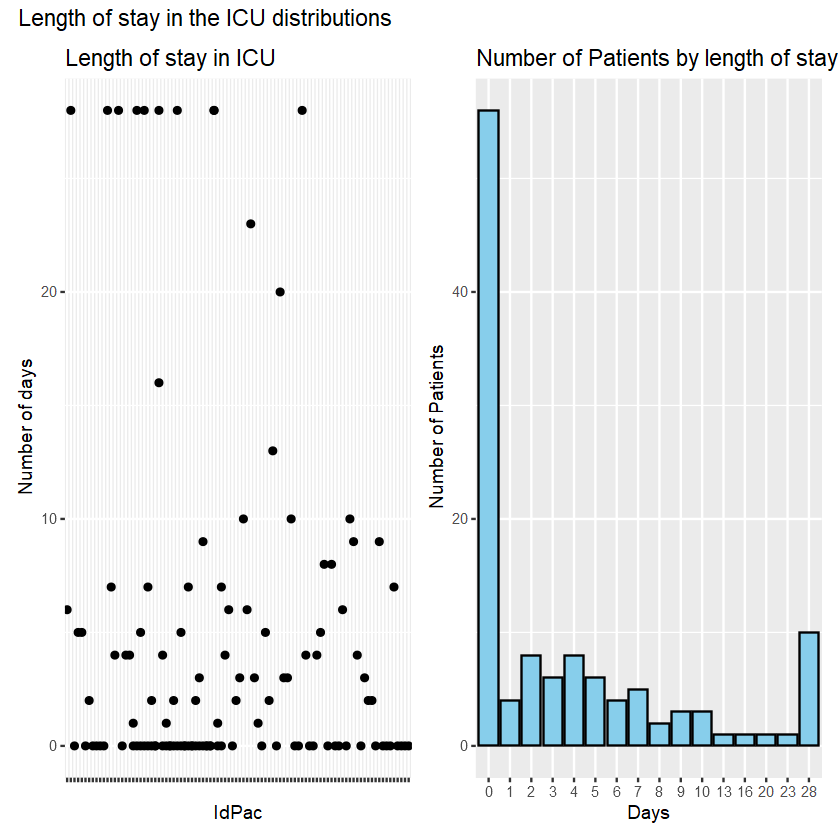

In [ ]:
#Graphicaly assert nature of data
# p1 in ggplot2
p1 <- ggplot(data_dint[!is.na(data_dint$EvolDiasUCI_tronq), ], aes(x = factor(IdPac), y = EvolDiasUCI_tronq)) +
  geom_point() +
  labs(title = "Length of stay in ICU", x = "IdPac", y = "Number of days") +
  theme(axis.text.x = element_blank())

# p2 in ggplot2
p2 <- ggplot(data_dint[!is.na(data_dint$EvolDiasUCI_tronq), ], aes(x = factor(EvolDiasUCI_tronq))) +
  geom_bar(fill = "skyblue", color = "black") +
  labs(title = "Number of Patients by length of stay in the ICU",
       x = "Days",
       y = "Number of Patients")

# Combine with patchwork
(p1 | p2) + plot_annotation(title = "Length of stay in the ICU distributions")


In [ ]:
#Evaluate dispersion
print(mean(data_dint$EvolDiasUCI_tronq, na.rm=TRUE))
print(var(data_dint$EvolDiasUCI_tronq, na.rm=TRUE))

[1] 4.907563


[1] 65.72867


With have an overdispersion

In [ ]:
#negative binomial to estimate los in ICU (truncated to 28 days)
nb_model_ <- with(imp,glm.nb(EvolDiasUCI_tronq ~Grupo, subset = UCI_Interm == 1))
summary(pool(nb_model_), conf.int=TRUE)

term,estimate,std.error,statistic,df,p.value,2.5 %,97.5 %
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.033175,0.2101871,9.673167,85.05814,2.330549e-15,1.6152707,2.4510789
Grupo1,-0.354744,0.3081297,-1.151282,85.05814,2.528424e-01,-0.9673823,0.2578943


In [ ]:
print(paste("Average stay of placebo group:", exp(2.033175)))
print(paste("Average stay of treatment group:", exp(2.033175-0.354744)))

[1] "Average stay of placebo group: 7.63829950099207"


[1] "Average stay of treatment group: 5.35714401470878"


#### Frequentist approach : likelihood maximum

##### Number of days in the ICU

Let's consider:
- X: the random variable representing the treatment group (0 for placebo) $X \in \{0,1\}$
- Y: the random variable to explain, representing the number of days spent in the ICU , $Y \in \{0,28\}$
- Z the variable which indicates if the patient died, $ Z \in \{0,1\}$.
X,Y and Z are not independent.

**Conditional probability formula**
$$
\begin{cases}
P(Y,Z \mid X) = \dfrac{P(Y,Z,X)}{P(X)} \\
P(Y \mid Z,X) = \dfrac{P(Y,Z,X)}{P(Z,X)} \\
P(Z,X) = P(Z \mid X) \, P(X)
\end{cases}
$$
So $P(Y,Z,X)=P(Y/Z,X)P(Z/X)P(X)$. Therefore:\\
$$
\boxed{P(Y,Z \mid X) = P(Y \mid Z,X)\, P(Z \mid X)}
$$

**Distribution of number of days in the ICU**
We model the number of days in the ICU (Y) considering treatment group (X) and death(Z). In particular, if the patient died (Z=1), the number of days is of 28 days (Y=28). So we have:
$$
\begin{cases}
Y \mid X=x, Z = 0 \sim \text{BN}(\mu_{x},\theta), x \in \{0,1\} \\
P(Y=28,Z=1/X)=P(Z=1/X)=\left(\frac{exp(\alpha_0 + \alpha_1 x)}{1+ exp(\alpha_0 + \alpha_1x)}\right) \cdot \mathbf{1}_{x \in \{0,1\}}
\end{cases}
$$
with:
- $\mu_{x} = \exp(\beta_0 + \beta_1 x)$ the average number of days spent in the ICU, which is considered dependent on the treatment
- P(Z=1/X), the probability of dying considering the treatment, modelled using a logistic regression

So $f_{Y \mid X,Z}(y\mid x,z)=f_{Y \mid X,Z=0}(y\mid x,z) \cdot \mathbf{1}_{z=0} + f_{Z=1 \mid X}(z\mid x) \cdot \mathbf{1}_{z=1}$ 

$$
\boxed{
\begin{aligned}
f_{Y \mid X,Z}(y \mid x,z) =\ & \frac{\Gamma(y + \theta)}{\Gamma(\theta)\, y!}
\left( \frac{\theta}{\theta + \mu_x} \right)^{\theta}
\left( \frac{\mu_x}{\theta + \mu_x} \right)^y
\left( \frac{1}{1 + \exp(\alpha_0 + \alpha_1 x)} \right)
\cdot\ \mathbf{1}_{\mathbb{N}}(y)
\cdot \mathbf{1}_{\{\mu_x, \theta  > 0\}}
\cdot \mathbf{1}_{x \in \{0,1\}}
\cdot \mathbf{1}_{z=0} \\
& + \left( \frac{\exp(\alpha_0 + \alpha_1 x)}{1 + \exp(\alpha_0 + \alpha_1 x)} \right)
\cdot \mathbf{1}_{x \in \{0,1\}}
\cdot \mathbf{1}_{z=1}
\end{aligned}
}
$$



We consider a sample ${\{(Y_1, X_1, Z_1), \ldots, (Y_n, X_n, Z_,)\}}$ drawn from ${(Y, X, Z)}$.\
The model is dominated by the counting measure $\delta$, and let $P_{\mu_{x,z},\theta}$ be the probability distribution associated with the model. Then, the density with respect to $\delta$ is given by:

$$
\frac{dP_{\mu_{x,z}, \theta}}{d\delta}(y) = f_{Y,Z \mid X}(y, z \mid x)
$$

a) The support of the density function does not depend on $\mu$ nor $\theta$, and the parameter space is open.\
b) The density function is $\mathcal{C}^\infty$ (infinitely differentiable) on the interval $]0, +\infty[^2$.

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}

\prod_{i=1}^n  \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i}} \right)^{\theta} \left( \frac{\mu_{X_i}}{\theta + \mu_{X_i}} \right)^{Y_i}\left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right) \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i \in \{0,1\}}} , & \text{for all i such that $Z_i$ =0} \\ 
\prod_{i=1}^n  \left(\frac{exp(\alpha_0 + \alpha_1X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right) \cdot \mathbf{1}_{X_i \in \{0,1\}}& \text{for all i such that $Z_i$ =1}

\end{cases}
$$

with $\mu_{X_i} = \exp(\beta_0 + \beta_1 X_i)$.

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}

 \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i}) + Y_i \log (\mu_{X_i}) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Z_i$ =0} \\
\sum_{i=1}^n \Biggl[ 
(\alpha_0 +\alpha_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] & \text{for all i such that $Z_i$ =1}

\end{cases}
$$

$$
\ell(\boldsymbol{\alpha, \beta}, \theta) =
\begin{cases}

 \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\exp(\beta_0 + \beta_1 X_i)) + Y_i\exp(\beta_0 + \beta_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Z_i$ =0} \\
\sum_{i=1}^n \Biggl[ 
(\alpha_0 +\alpha_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] & \text{for all i such that $Z_i$ =1}

\end{cases}
$$

In [ ]:
X<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))
Y<-as.numeric(as.character(data_dint$EvolDiasUCI_tronq[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))

In [ ]:
ll_NB_death<-function(params){
    a0 <- params[1]
    a1 <- params[2]
    b0 <- params[3]
    b1 <- params[4]
    X0<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
    X1<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1]))
    Y0<-as.numeric(as.character(data_dint$EvolDiasUCI_tronq[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
    mu <- exp(b0+b1*X0)
    theta<- mean(data_dint$EvolDiasUCI_tronq,na.rm=TRUE)^2/(var(data_dint$EvolDiasUCI_tronq, na.rm = TRUE)-mean(data_dint$EvolDiasUCI_tronq,na.rm=TRUE))
    ll_0<-sum(
      lgamma(Y0+theta)-
      lgamma(Y0+1)+
      theta* log(theta)-
      lgamma(theta)-
      (theta + Y0)*log(theta+mu)+
      Y0*log(mu)-
      log(1 + exp(a0+a1*X0))
    )
    ll_1<-sum(
      a0+a1*X1-
      log(1 + exp(a0+a1*X1))
    )
  ll <- ifelse(Z == 0, ll_0, ll_1) 
  return(ll)
}
Z<-as.numeric(as.character(data_dint$EvolMort28[!is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1]))

In [ ]:
#negative binomial to estimate los in ICU
nb_model <- with(
  imp,
  glm.nb(EvolDiasUCI_tronq ~ Grupo + EvolMort28, subset = UCI_Interm == 1)
)
summary(pool(nb_model))

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.53492137,0.1936029,7.9281926,84.05899,8.409724e-12
Grupo1,-0.08996325,0.2706619,-0.3323823,84.05899,7.404280e-01
EvolMort281,1.82050411,0.4486811,4.0574565,84.05899,1.105896e-04


In [ ]:
result <- maxLik(logLik = ll_NB_death, start = c(0,0,0,0))
summary(result)

--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 8 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -17277.85 
4  free parameters
Estimates:
     Estimate Std. error t value  Pr(> t)    
[1,] -4.23669    0.14141 -29.959  < 2e-16 ***
[2,] -1.07425    0.28291  -3.797 0.000146 ***
[3,]  1.53870    0.02873  53.550  < 2e-16 ***
[4,] -0.09768    0.04102  -2.381 0.017264 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
--------------------------------------------

In [ ]:
a0<--4.23669 
a1<--1.07425    
b0<-1.53870
b1<--0.09768

In [ ]:
print(paste("Estimated Probaility of death in placebo group:",round((exp(a0) / (1 + exp(a0)))*100,2), "%"))
print(paste("Estimated Probability of death in treatment group:",round((exp(a0+a1) / (1 + exp(a0+a1)))*100,2), "%"))
print(paste("Estimated Number of days in ICU for non dead patients in placebo group:", exp(b0)))
print(paste("Estimated Number of days in ICU for non dead patients in treatment group:", exp(b0+b1)))

[1] "Estimated Probaility of death in placebo group: 1.42 %"
[1] "Estimated Probability of death in treatment group: 0.49 %"
[1] "Estimated Number of days in ICU for non dead patients in placebo group: 4.65853024350716"
[1] "Estimated Number of days in ICU for non dead patients in treatment group: 4.22500312308255"


In [ ]:
print(paste("True Probability of death in placebo group:",
round((nrow(data_dint[data_dint$Grupo==0 & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90)*100,2), "%"))
print(paste("True Probability of death in treatment group:",
round((nrow(data_dint[data_dint$Grupo==1 & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90)*100,2), "%"))
print(paste("True Number of days in ICU for non dead patients in placebo group:", 
mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)))
print(paste("True Number of days in ICU for non dead patients in treatment group:",
mean(data_dint$EvolDiasUCI_tronq[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)))

[1] "True Probability of death in placebo group: 6.67 %"
[1] "True Probability of death in treatment group: 2.22 %"
[1] "True Number of days in ICU for non dead patients in placebo group: 4.65853658536585"
[1] "True Number of days in ICU for non dead patients in treatment group: 4.225"


The results match for number of days

In a regular model, we can  construct asymptotic confidence intervals for $\theta$ based on the maximum likelihood estimator. Indeed, the maximum likelihood estimator $\hat{\theta}_n$ is asymptotically efficient, which means:

$$
\sqrt{n}(\hat{\theta}_n - \theta) \xrightarrow{\mathcal{L}} \mathcal{N} \left(0, \frac{1}{I(\theta)}\right)
$$

Hence, an asymptotic confidence interval of level $1 - \alpha$ is given by:

$$
\left[
\hat{\theta}_n - z_{1 - \alpha/2} \cdot \sqrt{\frac{1}{n I(\hat{\theta}_n)}}, \;
\hat{\theta}_n + z_{1 - \alpha/2} \cdot \sqrt{\frac{1}{n I(\hat{\theta}_n)}}
\right]
$$

where $z_{1 - \alpha/2}$ is the $(1 - \alpha/2)$ quantile of the standard normal distribution, and $I(\hat{\theta}_n)$ is the Fisher information evaluated at $\hat{\theta}_n$.


In [ ]:
# 1) Redefine log_likelihood:
ll_raw <- function(alpha0, alpha1, beta0, beta1) {
  mu  <- exp(beta0 + beta1 * X)
  eta <- alpha0 + alpha1 * X
  
  # for Z=0
  idx0 <- which(Z == 0)
  theta<- mean(Y[idx0],na.rm=TRUE)^2/(var(Y[idx0], na.rm = TRUE)-mean(Y[idx0],na.rm=TRUE))
  term0 <- sum(
    lgamma(Y[idx0] + theta) - lgamma(theta) - lgamma(Y[idx0] + 1) +
    theta * log(theta / (theta + mu[idx0])) +
    Y[idx0] * log(mu[idx0] / (theta + mu[idx0])) -
    log(1 + exp(eta[idx0]))
  )
  
  # for Z=1
  idx1 <- which(Z == 1)
  term1 <- sum(
    eta[idx1] - log(1 + exp(eta[idx1]))
  )
  
  return(term0 + term1)
}

ll <- function(p) {
  alpha0 <- p[1]
  alpha1 <- p[2]
  beta0  <- p[3]
  beta1  <- p[4]
  ll_raw(alpha0, alpha1, beta0, beta1)
}

# 2) Calculate Hessian
p_hat <- c(a0, a1, b0, b1)

info_fisher <- -hessian(ll, p_hat)
print(info_fisher)


             [,1]          [,2]         [,3]          [,4]
[1,] 8.655090e-01  2.053337e-01 0.000000e+00  4.768372e-07
[2,] 2.053337e-01  2.053337e-01 4.768372e-07 -4.768372e-07
[3,] 0.000000e+00  4.768372e-07 4.653297e+01  2.283207e+01
[4,] 4.768372e-07 -4.768372e-07 2.283207e+01  2.283207e+01


In [ ]:
IC_a0=c(a0 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[1,1]), a0+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[1,1]))
IC_a1=c(a1 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[2,2]), a1+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[2,2]))
IC_b0=c(b0 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[3,3]), b0+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[3,3]))
IC_b1=c(b1 - qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[4,4]), b1+ qnorm(p = 0.95, mean=0, sd=1)*sqrt(1/90*info_fisher[4,4]))
IC_b1

[1] -0.9261535  0.7307935

Let's add interraction terms. We consider:
- X: the random variable representing the treatment group (0 for placebo) $X \in \{0,1\}$
- Y: the random variable to explain, representing the number of days spent in the ICU , $Y \in \{0,28\}$
- Z the variable which indicates if the patient died, $ Z \in \{0,1\}$.
X,Y and Z are not independent.
- $ W \in \mathbb{R}^p $: a vector of covariates (interraction terms)

**Distribution of number of days in the ICU**
We model the number of days in the ICU (Y) considering treatment group (X), interraction terms and death(Z). In particular, if the patient died (Z=1), the number of days is of 28 days (Y=28). So we have:
$$
\begin{cases}
Y \mid X=x, Z = 0 \sim \text{BN}(\mu_{x,w},\theta), x \in \{0,1\}, w \in \mathbb{N}^p  \\
P(Y=28,Z=1/X, W)=P(Z=1/X,W)=\left(\frac{exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_j w_j + \sum_{j=1}^p \zeta_j(x*w_j)) }{1+ exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_jW_j + \sum_{j=1}^p \zeta_j(x \cdot w_j))}\right) \cdot \mathbf{1}_{x \in \{0,1\}} \cdot \mathbf{1}_{w \in \mathbb{N}^p}
\end{cases}
$$
with:
- $\mu_{x,w} = \exp(\beta_0 + \beta_1 x + \sum_{j=1}^p \gamma_j w_j + \sum_{j=1}^p \nu_j(x*w_j))$ the average number of days spent in the ICU, which is considered dependent on the treatment
- P(Z=1/X,W), the probability of dying considering the treatment and covariates, modelled using a logistic regression

So $f_{Y \mid X,Z}(y\mid x,z)=f_{Y \mid X,Z=0}(y\mid x,z) \cdot \mathbf{1}_{z=0} + f_{Z=1 \mid X}(z\mid x) \cdot \mathbf{1}_{z=1}$ 

$$
\boxed{
\begin{aligned}
f_{Y \mid X,Z}(y \mid x,z) =\ & \frac{\Gamma(y + \theta)}{\Gamma(\theta)\, y!}
\left( \frac{\theta}{\theta + \mu_{x,w}} \right)^{\theta}
\left( \frac{\mu_x}{\theta + \mu_{x,w}} \right)^y
\left( \frac{1}{1 + exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_jW_j + \sum_{j=1}^p \zeta_j(x \cdot w_j))} \right)
\cdot\ \mathbf{1}_{\mathbb{N}}(y)
\cdot \mathbf{1}_{\{\mu_{x,w}, \theta  > 0\}}
\cdot \mathbf{1}_{x \in \{0,1\}}
\cdot \mathbf{1}_{z=0} \cdot \mathbf{1}_{w \in \mathbb{N}^p} \\
& + \left( \frac{exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_j w_j + \sum_{j=1}^p \zeta_j(x \cdot w_j))}{1 + exp(\alpha_0 + \alpha_1 x+ \sum_{j=1}^p \eta_j w_j + \sum_{j=1}^p \zeta_j(x \cdot w_j))} \right)
\cdot \mathbf{1}_{x \in \{0,1\}}
\cdot \mathbf{1}_{z=1} \cdot \mathbf{1}_{w \in \mathbb{N}^p}
\end{aligned}
}
$$



We consider a sample ${\{(Y_1, X_1, Z_1, W_1), \ldots, (Y_n, X_n, Z_n,W_n)\}}$ drawn from ${(Y, X, Z, W)}$.\

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}

\prod_{i=1}^n  \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i,W_i}} \right)^{\theta} \left( \frac{\mu_{X_i,W_i}}{\theta + \mu_{X_i,W_i}} \right)^{Y_i}\left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij}))}\right) \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i,W_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i \in \{0,1\}}} \cdot \mathbf{1}_{W_i \in \mathbb{N}^p} , & \text{for all i such that $Z_i$ =0} \\ 
\prod_{i=1}^n  \left(\frac{ exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij}))}{1+  exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij}))}\right) \cdot \mathbf{1}_{X_i \in \{0,1\}} \cdot \mathbf{1}_{W_i \in \mathbb{N}^p}& \text{for all i such that $Z_i$ =1}

\end{cases}
$$

with  $\mu_{X_i,W_i} = \exp(\beta_0 + \beta_1 x + \sum_{j=1}^p \gamma_j W_{ij} + \sum_{j=1}^p \nu_j(Xi*W_{ij}))$

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}

 \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i, W_i}) + Y_i \log (\mu_{X_i,W_i}) - log(1 + exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij})))
\Biggr] , & \text{for all i such that $Z_i$ =0} \\
\sum_{i=1}^n \Biggl[ 
(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij})) - log(1 + exp(\alpha_0 + \alpha_1X_i + \sum_{j=1}^p \eta_jW_{ij} + \sum_{j=1}^p \zeta_j(x \cdot W_{ij})))
\Biggr] & \text{for all i such that $Z_i$ =1}

\end{cases}
$$



In [137]:
ll_NB_death_interraction <- function(params, W){
  p <- length(W)  # number of covariates
  
  a0 <- params[1]
  a1 <- params[2]
  b0 <- params[3]
  b1 <- params[4]
  
  eta  <- params[5:(4+p)]        # logistic main effects
  zeta <- params[(5+p):(4+2*p)]  # logistic interactions
  
  gamma <- params[(5+2*p):(4+3*p)]  # NB main effects
  delta <- params[(5+3*p):(4+4*p)]  # NB interactions
  
  # Extract data
  idx <- !is.na(data_dint$EvolDiasUCI_tronq) & data_dint$UCI_Interm==1
  X <- as.numeric(as.character(data_dint$Grupo[idx]))
  Y <- as.numeric(as.character(data_dint$EvolDiasUCI_tronq[idx]))
  Z <- as.numeric(as.character(data_dint$EvolMort28[idx]))
  
  Wmat <- as.matrix(sapply(data_dint[idx,W ], as.numeric))
  
  # Linear predictors
  logit_p <- a0 + a1*X + Wmat %*% eta + (X*Wmat) %*% zeta
  mu      <- exp(b0 + b1*X + Wmat %*% gamma + (X*Wmat) %*% delta)
  
  # NB dispersion (method of moments estimate, but could make param)
  theta <- mean(Y,na.rm=TRUE)^2 / (var(Y,na.rm=TRUE)-mean(Y,na.rm=TRUE))
  
  # Likelihood contributions
  ll <- numeric(length(Y))
  
  # survivors
  surv <- which(Z==0)
  ll[surv] <- lgamma(Y[surv]+theta) -
              lgamma(Y[surv]+1) +
              theta*log(theta) -
              lgamma(theta) -
              (theta+Y[surv])*log(theta+mu[surv]) +
              Y[surv]*log(mu[surv]) -
              log(1+exp(logit_p[surv]))
  
  # deaths
  died <- which(Z==1)
  ll[died] <- logit_p[died] - log(1+exp(logit_p[died]))
  
  return(sum(ll))
}


In [139]:
W <- c("Sexo")
ll_fun <- function(params) {
  ll_NB_death_interraction(params, W = W)
}
result_W <- maxLik(logLik = ll_fun,start = rep(0, 4 + 4*length(W)))
summary(result_W)


--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 6 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -230.4104 
8  free parameters
Estimates:
     Estimate Std. error t value Pr(> t)  
[1,]  -0.6991     1.3621  -0.513   0.608  
[2,]  -1.8318     2.5089  -0.730   0.465  
[3,]  -0.3059     0.8344  -0.367   0.714  
[4,]   1.5594     1.0987   1.419   0.156  
[5,]  -0.7673     0.8491  -0.904   0.366  
[6,]   0.4649     1.5933   0.292   0.770  
[7,]   1.0368     0.4718   2.197   0.028 *
[8,]  -0.9188     0.6410  -1.433   0.152  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
--------------------------------------------

In [ ]:
a0<--0.6991
a1<--1.8318
b0<--0.3059
b1<-1.5594
eta<--0.7673
zeta<-0.4649
gamma<-1.0368
nu<--0.9188

print(paste("Estimated Probaility of death in placebo group:",round((exp(a0) / (1 + exp(a0)))*100,2), "%"))
print(paste("Estimated Probability of death in treatment group:",round((exp(a0+a1) / (1 + exp(a0+a1)))*100,2), "%"))
print(paste("Estimated Number of days in ICU for non dead patients in placebo group:", exp(b0)))
print(paste("Estimated Number of days in ICU for non dead patients in treatment group:", exp(b0+b1)))

##### Ventilation-free days

In [ ]:
#Create ventilation-free days variables
data_dint$vf_days<-28 - data_dint$EvolDiasUCI_tronq

#Initializa parameters
X0<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$vf_days) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
Y0<-as.numeric(as.character(data_dint$vf_days[!is.na(data_dint$vf_days) & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1]))
mu <- exp(b0+b1*X0)
theta<- mean(Y0,na.rm=TRUE)^2/(var(Y0, na.rm = TRUE)-mean(Y0,na.rm=TRUE))

#Proportion of zeros in NB model
p_nb_treatment=mean(((theta/(theta+mu))^theta)*(1/(1+exp(a0+a1)))) #treatment
p_nb_placebo=mean(((theta/(theta+mu))^theta)*(1/(1+exp(a0)))) #placebo
p_nb=(nrow(data_dint[data_dint$Grupo==1,])/nrow(data_dint))*p_nb_treatment+ (nrow(data_dint[data_dint$Grupo==0,])/90)*p_nb_placebo
#Proportion of structural zeros
pst=nrow(data_dint[data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90


print(paste("Proportion of structural zeros",round(pst*100,2),"%"))
print(paste("Proportion of nb zeros",round(p_nb*100,2),"%"))

[1] "Proportion of structural zeros 8.89 %"
[1] "Proportion of nb zeros 1.66 %"


Structural zeros > negative binomial zeros. Let's try a zero-inflated negative binomial model
$$
f_{Y \mid X,Z}(y\mid x,z)= 
\begin{cases}
\Biggl[\pi \left(\frac{exp(\alpha_0 + \alpha_1 x)}{1+ exp(\alpha_0 + \alpha_1x)}\right)  + (1-\pi)\left(\frac{\theta}{\theta + \mu_{x}}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1x)}\right)\Biggl]\cdot \mathbf{1}_{\{\mu_{x} > 0, \theta > 0\}} \cdot \mathbf{1}_{x \in \{0,1\}} , & \text{if y=0}    \\
(1-\pi)\frac{\Gamma(y + \theta)}{y! \ \Gamma(\theta)} \left(\frac{\theta}{\theta + \mu_{x}}\right)^{\theta} \left(\frac{\mu_{x}}{\theta + \mu_{x}}\right)^y \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1x)}\right)\cdot \mathbf{1}_{\mathbb{N}}(y) \cdot \mathbf{1}_{\{\mu_{x} > 0, \theta > 0\}} \cdot \mathbf{1}_{x \in \{0,1\}}, & \text{if y>0}
\end{cases}
$$

We consider a sample ${\{(Y_1, X_1, Z_1), \ldots, (Y_n, X_n, Z_,)\}}$ drawn from ${(Y, X, Z)}$.\

The likelihood is given by:

$$
L(\boldsymbol{\mu, \theta}) = 
\begin{cases}
\prod_{i=1}^n \Biggl[\pi \left(\frac{exp(\alpha_0 + \alpha_1 X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)  + (1-\pi)\left(\frac{\theta}{\theta + \mu_{X_i}}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)\Biggl]\cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} , & \text{for all i such that  $Y_i$ =0 }\\
(1-\pi)^n\prod_{i=1}^n  \frac{\Gamma(Y_i + \theta)}{\Gamma(\theta) \, Y_i!} \left( \frac{\theta}{\theta + \mu_{X_i}} \right)^{\theta} \left( \frac{\mu_{X_i}}{\theta + \mu_{X_i}} \right)^{Y_i}\left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right) \cdot \mathbf{1}_{\mathbb{N}}(Y_i) \cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\} \cdot \mathbf{1}_{X_i \in \{0,1\}}} , & \text{for all i such that $Y_i$ >0}

\end{cases}
$$

with $\mu_{X_i} = \exp(\beta_0 + \beta_1 X_i)$.

The log-likelihood is:

$$
\ell(\boldsymbol{\mu}, \theta) =
\begin{cases}
\sum_{i=1}^n 
\log \Biggl[\pi \left(\frac{exp(\alpha_0 + \alpha_1 X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)  + (1-\pi)\left(\frac{\theta}{\theta + \mu_{X_i}}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)\Biggl]\cdot \mathbf{1}_{\{\mu_{X_i} > 0, \theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}} , & \text{for all i such that $Y_i$ =0 } \\
 n\log (1-\pi) + \sum_{i=1}^n \Biggl[ 
 \log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\mu_{X_i}) + Y_i \log (\mu_{X_i}) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Y_i$ >0} 

\end{cases}
$$

$$
\ell(\boldsymbol{\alpha, \beta}, \theta) =
\begin{cases}
\sum_{i=1}^n  
\log \Biggl[\pi \left(\frac{exp(\alpha_0 + \alpha_1 X_i)}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)  + (1-\pi)\left(\frac{\theta}{\theta + \exp(\beta_0 + \beta_1 X_i)}\right)^{\theta} \left(\frac{1}{1+ exp(\alpha_0 + \alpha_1X_i)}\right)\Biggl]\cdot \mathbf{1}_{\{\theta > 0\}} \cdot \mathbf{1}_{X_i \in \{0,1\}}
 , & \text{for all i such that  $Y_i$ =0 } \\
 n\log (1-\pi) + \sum_{i=1}^n \Biggl[ 
\log \Gamma(Y_i + \theta) - \log (Y_i!) + \log \left(\frac{\theta^{\theta}}{\Gamma(\theta)}\right)- (\theta + Y_i) \log (\theta +\exp(\beta_0 + \beta_1 X_i)) + Y_i\exp(\beta_0 + \beta_1 X_i) - log(1 + exp(\alpha_0 +\alpha_1 X_i))
\Biggr] , & \text{for all i such that $Y_i$ >0}

\end{cases}
$$

In [ ]:
ll_ZINB_death<-function(params){
    a0 <- params[1]
    a1 <- params[2]
    b0 <- params[3]
    b1 <- params[4]
    X0<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$vf_days) & data_dint$vf_days==0  & data_dint$UCI_Interm==1]))
    X1<-as.numeric(as.character(data_dint$Grupo[!is.na(data_dint$vf_days)& data_dint$vf_days>0  & data_dint$UCI_Interm==1]))
    Y1<-as.numeric(as.character(data_dint$vf_days[!is.na(data_dint$vf_days)& data_dint$vf_days>0  & data_dint$UCI_Interm==1]))
    mu_0 <- exp(b0+b1*X0)
    mu_1 <- exp(b0+b1*X1)
    theta<- mean(data_dint$vf_days,na.rm=TRUE)^2/(var(data_dint$vf_days, na.rm = TRUE)-mean(data_dint$vf_days,na.rm=TRUE))
    ll_0<-sum(
      log(
        pst*(exp(a0+a1*X0)/(1+exp(a0+a1*X0)))+
        (1-pst)*((theta/(theta+mu_0))^theta)*(1/(1+exp(a0+a1*X0)))
      )
    )
    ll_1<-120*log (1-pst) + sum(
      lgamma(Y1+theta)-
      lgamma(Y1+1)+
      theta* log(theta)-
      lgamma(theta)-
      (theta + Y1)*log(theta+mu_1)+
      Y1*log(mu_1)-
      log(1 + exp(a0+a1*X1))
    )
  ll <- ifelse(Y==0, ll_0, ll_1)

  return(ll)
}

In [ ]:
result <- maxLik(logLik = ll_ZINB_death, start = c(0,0,0,0))
summary(result)

--------------------------------------------
Maximum Likelihood estimation
Newton-Raphson maximisation, 7 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-Likelihood: -18458.93 
4  free parameters
Estimates:
      Estimate Std. error t value  Pr(> t)    
[1,] -2.628236   0.076514 -34.350  < 2e-16 ***
[2,] -0.822187   0.135645  -6.061 1.35e-09 ***
[3,]  3.174908   0.006955 456.469  < 2e-16 ***
[4,]  0.019031   0.009882   1.926   0.0541 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
--------------------------------------------

In [ ]:
print(paste("Estimated Probability of death in placebo group:",round((exp(-2.628236   ) / (1 + exp(-2.628236   )))*100,2), "%"))
print(paste("Estimated Probaility of death in treatment group:",round((exp(-2.628236   -0.822187   ) / (1 + exp(-2.628236   -0.822187   )))*100,2), "%"))
print(paste("Estimated Number of ventilation-free days for non dead patients in placebo group:", exp(3.174908   )))
print(paste("Estimated Number of ventilation-free days for non dead patients in treatment group:", exp(3.174908   +0.019031   )))

[1] "Estimated Probability of death in placebo group: 6.73 %"
[1] "Estimated Probaility of death in treatment group: 3.08 %"
[1] "Estimated Number of ventilation-free days for non dead patients in placebo group: 23.9246187022024"
[1] "Estimated Number of ventilation-free days for non dead patients in treatment group: 24.3842882326722"


In [ ]:
print(paste("True Probability of death in placebo group:",
round((nrow(data_dint[data_dint$Grupo==0 & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90)*100,2), "%"))
print(paste("True Probability of death in treatment group:",
round((nrow(data_dint[data_dint$Grupo==1 & data_dint$EvolMort28==1 & data_dint$UCI_Interm==1,])/90)*100,2), "%"))
print(paste("True Number of ventilation-free days for non dead patients in placebo group:", 
mean(data_dint$vf_days[data_dint$Grupo==0 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)))
print(paste("True Number of ventilation-free days for non dead patients in treatment group:",
mean(data_dint$vf_days[data_dint$Grupo==1 & data_dint$EvolMort28==0 & data_dint$UCI_Interm==1], na.rm=TRUE)))


[1] "True Probability of death in placebo group: 6.67 %"
[1] "True Probability of death in treatment group: 2.22 %"
[1] "True Number of ventilation-free days for non dead patients in placebo group: 23.3414634146341"
[1] "True Number of ventilation-free days for non dead patients in treatment group: 23.775"


Results match for proportion of deat and number of days

#### Bayesian approach

Let's consider:\
X: random variable representing the treatment group (0 for placebo)\
Y: random variable representing the number of ventilation-free days\
Z: random varaible representing death (1 for death)

$Y=y \mid X=x, Z=0 \sim \text{BN}(p(x), \theta), \text{and} Z=z,\mid X=x \sim \text{B}(\gamma(x)) x,z \in \{0,1\}$ 
where :
- $ \gamma(x)=P(Z=1 \mid X)= \frac{exp(\alpha_0+\alpha_1x)}{1+exp(\alpha_0+\alpha_1x)}  $
- $E(Y)=\mu(x) = \theta\frac{1-p(x)}{p(x)}$ with $\mu(x)=exp(\beta_0 + \beta_1x)$, so $p(x)=\frac{\theta}{exp(\beta_0 + \beta_1x)+\theta}$\
According to Bayes formula:
$
\psi(\beta, \theta/y)\approx f(y/\beta, \theta)\pi(\beta)\phi(\theta)$ (we suppose $\theta$ and $\beta$ independant)
, 
with:
- $\beta =(\beta_0, \beta_1) \sim \text{N}(\mu, \Sigma)$ where $\Sigma=\binom{\sigma_0^{2}   \rho_{\sigma_0\sigma_1}}{\rho_{\sigma_0 \sigma_1}  \sigma_1^{2}}$ and $ \mu = \binom{\mu_0}{\mu_1}$
- $ \pi(\beta)=\frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}$
- $f(y/\beta, \theta)= \pi \gamma(x) \mathbf{1}_{y=0}+ (1-\pi)\binom{y+\theta-1}{y}p^{\theta}(1-p)^y$ with $\pi$= probability of structural zeros= probability of death
- We suppose $\theta \sim \Gamma(a,b)$:
$ \phi(\theta)= \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} $\
considering a sample $(x,y,z)=((x_1,y_1,z_1),..., (x_n,y_n,z_n))$\
Finally:
$$
\psi(\beta, \theta/y)\approx \theta^{a-1}\frac{b^a e{-b\theta}}{\Gamma{a}} \frac{exp(-\frac{1}{2}(\beta-\mu)^T\Sigma^-1(\beta-\mu))}{2\pi|\Sigma|^\frac{1}{2}}\Biggl [\pi \gamma(x) \mathbf{1}_{y=0}+ (1-\pi)\binom{y+\theta-1}{y}p^{\theta}(1-p)^y \Biggr]
$$


* For all the scenarios we consider: $\theta \sim \Gamma(0.05,0.01), \text{IC}_{95\%} = ]0, 56.7]$\
=> Very large range so no concrete information on the overdispersion, but the true value of 12.5 is in the interval\
$\alpha_0 ,\alpha_1, \sim \text{N}(0,10), \text{IC}_{95\%} = [-6.2, 6.2]$\
=> We have a large range so we're not sure if the treatment works or not on death 


* **Non informative scenario**: \
$\beta_0 ,\beta_1 \sim \text{N}(0,10), \text{IC}_{95\%} = [-6.2, 6.2]$\
=> We have a large range so we're not sure if the treatment works or not on number of ventilation-free days


* **Optimistic scenario**: \
$\beta_0 \sim \text{N}(2.3,0.3), \text{IC}_{95\%} = [1.23, 3.37]$, IC for number of days for placebo group : [3.4, 29.18]\
$\beta_1 \sim \text{N}(1.1,0.3), \text{IC}_{95\%} = [0.02, 2.17]$\
=> The treatment increase the number of ventilation-free days. The mean number of days for the non dead placebo group is in the IC


* **Pessimistic scenario**: \
$\beta_0 \sim \text{N}(2.3,0.3)$\
$\beta_1 \sim \text{N}(0,0.3), \text{IC}_{95\%} = [-1.1, 1.1]$\
=> The treatment may have no effect (0 in the IC)\


In [ ]:
df<-data_dint[data_dint$UCI_Interm==1,]
modelString_zinb="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(0,0.1)
  beta1 ~ dnorm(0,0.1)
  
} 
"
modelString_zinb_op="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(2.3,3.333)
  beta1 ~ dnorm(1.1,3.333)
  
} 
"
modelString_zinb_pess="
model {
  for (i in 1:N) {
     z[i] ~ dbern(pi[i])
     pi[i] <- exp(alpha0+alpha1*X[i])/(1+exp(alpha0+alpha1*X[i]))
     Y[i] ~ dnegbin(p[i], theta)
     Y_pred[i] ~ dnegbin(p[i], theta)
     loglik[i] <- logdensity.negbin(Y[i], p[i], theta)
     p[i] <- (theta/(exp(beta0 + beta1*X[i])+theta))*(1-z[i]) + z[i]
  }
  alpha0 ~ dnorm(0,0.1)
  alpha1 ~ dnorm(0,0.1)
  theta~ dgamma(0.05, 0.01)
  beta0 ~ dnorm(2.3,3.333)
  beta1 ~ dnorm(1.1,3.333)
  
} 
"
bmod_zinb <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo" ,modelString = modelString_zinb)
bmod_zinb_op <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo", modelString = modelString_zinb_op)
bmod_zinb_pess <- BayesianModel$new(data = df, Y = "vf_days", X = "Grupo", modelString = modelString_zinb_pess)

In [ ]:
mod_zinb<- bmod_zinb$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb<- bmod_zinb$sample(model = mod_zinb, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)
mod_zinb_op<- bmod_zinb_op$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb_op<- bmod_zinb_op$sample(model = mod_zinb_op, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)
mod_zinb_pess<- bmod_zinb_pess$model(nchains = 3, nadapt = 1000, burnin = 9000)
samp_zinb_pess<- bmod_zinb_pess$sample(model = mod_zinb_pess, variable_names = c("alpha0", "alpha1","beta0", "beta1","theta"), niter =25000, thin = 15)


Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 751

Initializing model

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 754

Initializing model

Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 89
   Unobserved stochastic nodes: 186
   Total graph size: 754

Initializing model



[1] "Non informative"
[1] "Optimistic"


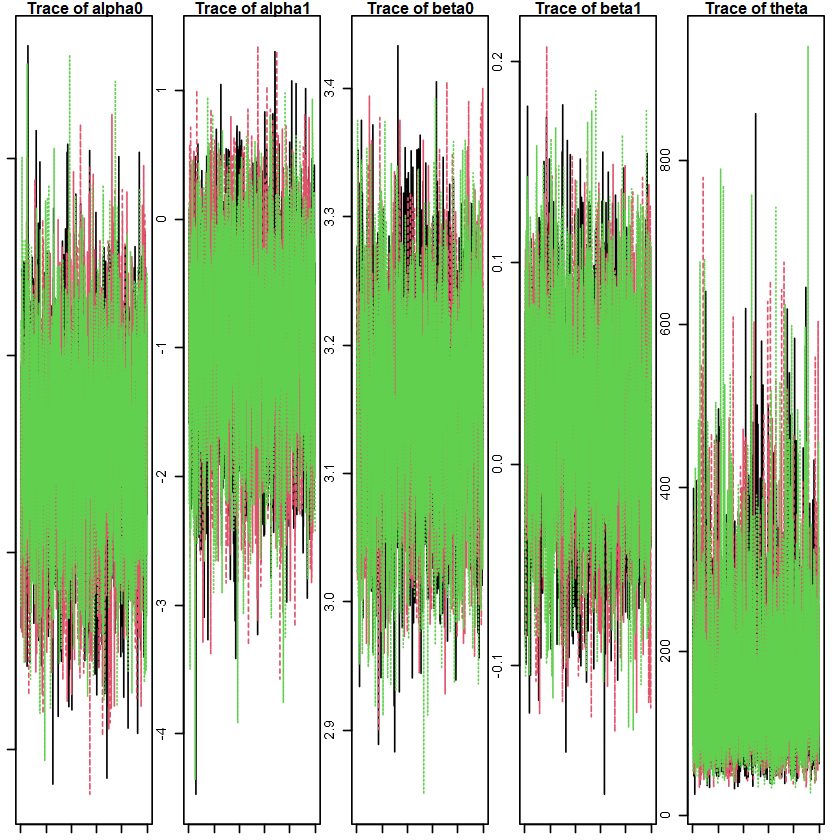

[1] "Pessimistic"


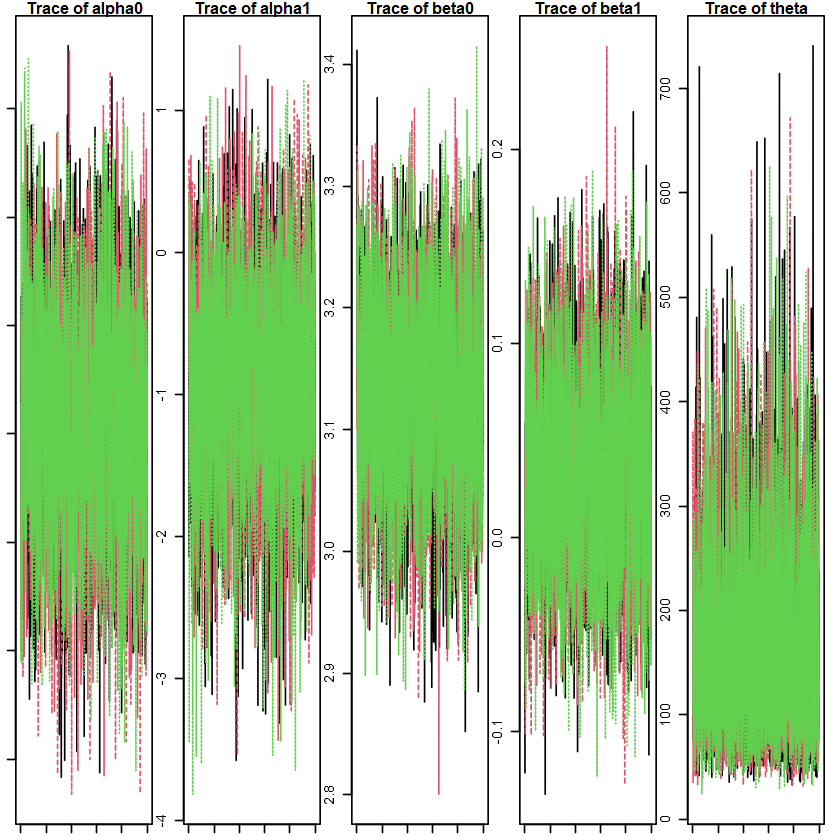

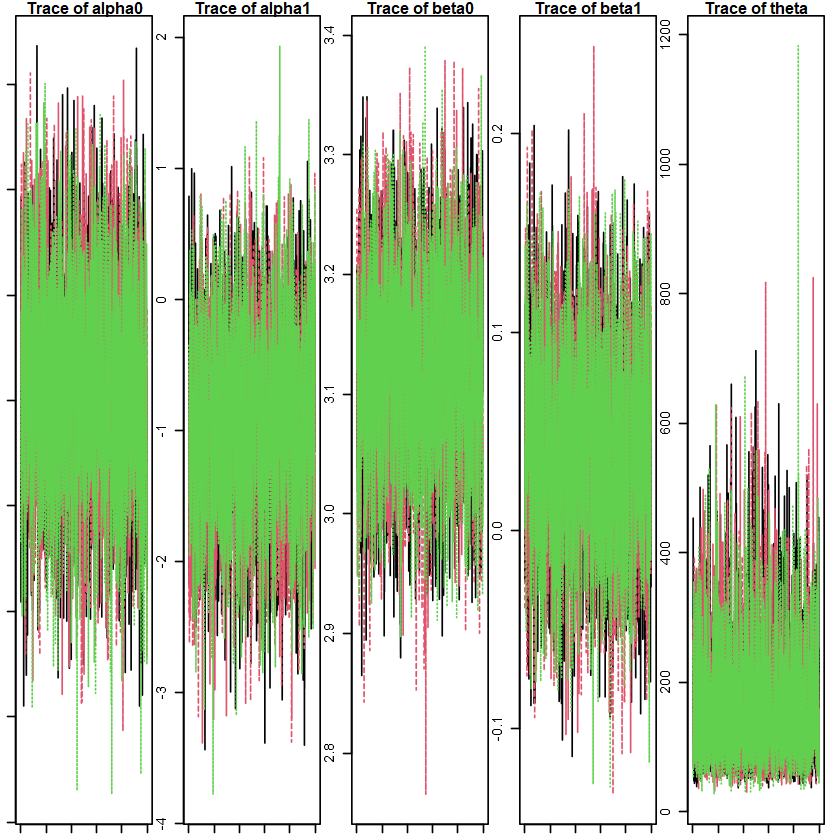

In [ ]:
par(mfrow = c(1, 5), mar=c(1,1,1,1))

print("Non informative")
bmod_zinb$graphs(samp_zinb, type_of_graph = "traceplot")
print("Optimistic")
bmod_zinb_op$graphs(samp_zinb_op, type_of_graph = "traceplot")
print("Pessimistic")
bmod_zinb_pess$graphs(samp_zinb_pess, type_of_graph = "traceplot")


par(mfrow = c(1,1))


In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "gelman")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "gelman")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "gelman")

[1] "Non informative"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1       1.00
alpha1          1       1.00
beta0           1       1.01
beta1           1       1.01
theta           1       1.00

Multivariate psrf

1

[1] "Optimistic"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1       1.00
alpha1          1       1.00
beta0           1       1.02
beta1           1       1.02
theta           1       1.00

Multivariate psrf

1

[1] "Pessimistic"


Potential scale reduction factors:

       Point est. Upper C.I.
alpha0          1       1.00
alpha1          1       1.01
beta0           1       1.00
beta1           1       1.00
theta           1       1.00

Multivariate psrf

1

In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "autocorr")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "autocorr")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "autocorr")

[1] "Non informative"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.000000000,1.000000000,1.000000000,1.000000000,1.000000000
Lag 15,0.305429620,0.318926647,0.348506892,0.351343442,0.013550880
Lag 75,0.012921897,0.008095764,0.009007961,-0.004577442,-0.005249269
Lag 150,-0.002587619,-0.015917658,0.010728006,0.011034360,-0.024008056
Lag 750,0.015550450,0.013744099,-0.019083467,-0.018041619,0.004344449


[1] "Optimistic"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.000000000,1.0000000000,1.000000000,1.00000000,1.000000000
Lag 15,0.307944707,0.3101887669,0.362148703,0.36482563,0.012242770
Lag 75,0.023959466,0.0238732099,0.038012699,0.05221922,-0.004110023
Lag 150,-0.003430938,-0.0003666516,-0.035674626,-0.03478142,-0.006225156
Lag 750,0.015545316,0.0126505110,-0.009507445,-0.01858137,0.031165992


[1] "Pessimistic"


,alpha0,alpha1,beta0,beta1,theta
Lag 0,1.0000000000,1.000000000,1.000000000,1.000000000,1.000000000
Lag 15,0.2804001279,0.275241894,0.356240587,0.346712127,-0.002964683
Lag 75,-0.0099639267,-0.020249167,-0.002933517,-0.006041228,-0.019095996
Lag 150,0.0005905279,0.006212718,-0.007974756,-0.010779892,0.014563627
Lag 750,0.0101520942,0.006227378,-0.035684224,-0.044973740,0.032843873


In [ ]:
print("Non informative")
bmod_zinb$metrics(samp_zinb, type_of_metric = "effectivesize")
print("Optimistic")
bmod_zinb_op$metrics(samp_zinb_op, type_of_metric = "effectivesize")
print("Pessimistic")
bmod_zinb_pess$metrics(samp_zinb_pess, type_of_metric = "effectivesize")

[1] "Non informative"


alpha0   alpha1    beta0    beta1    theta 
2623.685 2582.981 2413.346 2397.713 4682.367

[1] "Optimistic"


alpha0   alpha1    beta0    beta1    theta 
2940.491 2624.633 2195.781 2199.416 4998.000

[1] "Pessimistic"


alpha0   alpha1    beta0    beta1    theta 
2788.271 2937.578 2507.936 2593.654 5044.629

[1] "Non informative"
[1] "optimistic"


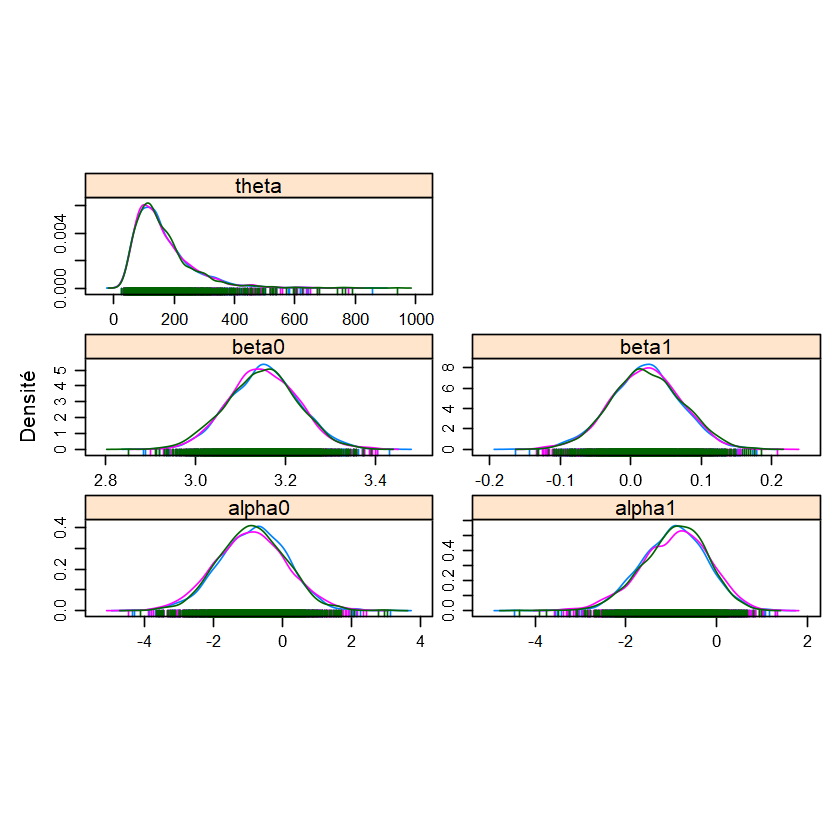

[1] "pessimistic"


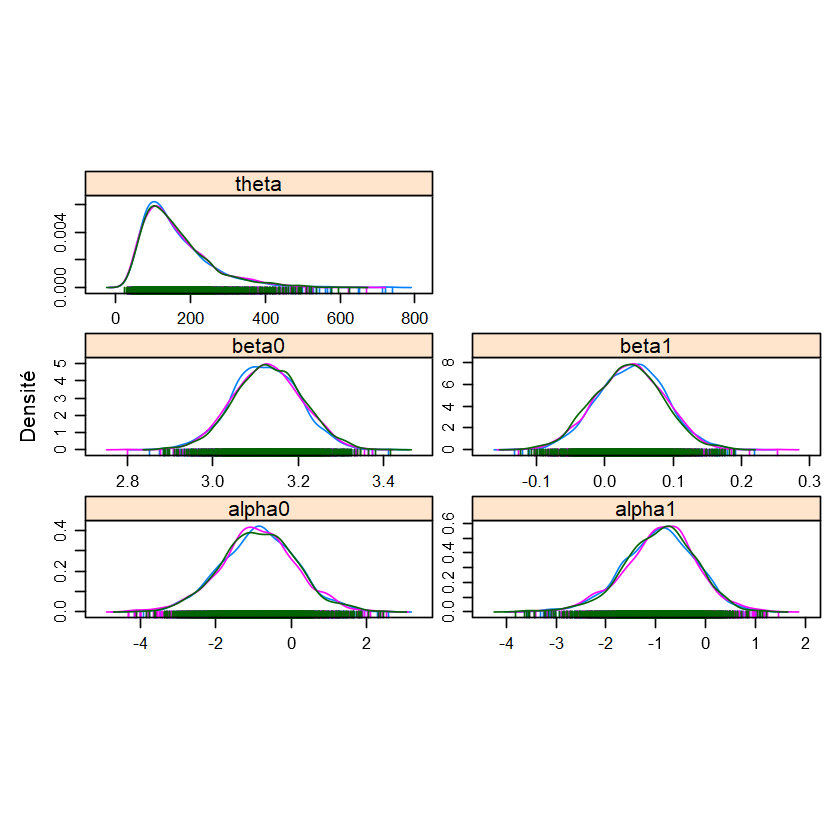

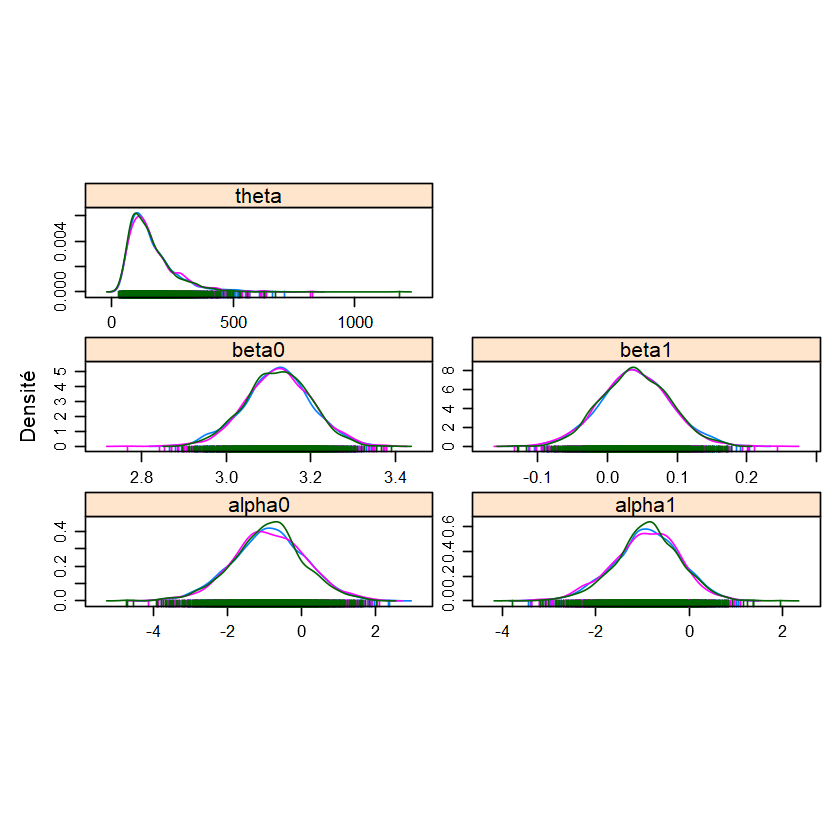

In [ ]:
par(mfrow = c(1, 5), mar=c(1,1,1,1))

print("Non informative")
bmod_zinb$graphs(samp_zinb, type_of_graph = "density")
print("optimistic")
bmod_zinb_op$graphs(samp_zinb_op, type_of_graph = "density")
print("pessimistic")
bmod_zinb_pess$graphs(samp_zinb_pess, type_of_graph = "density")


par(mfrow = c(1,1))


In [ ]:
lik_zinb<-rowSums(as.matrix(bmod_zinb$likelihood(model = mod_zinb,  likelihood_name="loglik", niter = 25000, thin = 15) )))

lik_zinb_op<-rowSums(as.matrix(bmod_zinb_op$likelihood(model = mod_zinb_op,  likelihood_name="loglik", niter = 25000, thin = 15)))

lik_zinb_pess<-rowSums(as.matrix(bmod_zinb_pess$likelihood(model = mod_zinb_pess,  likelihood_name="loglik", niter = 25000, thin = 15)))


In [ ]:
scale_minmax <- function(x) (x - min(x,na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))

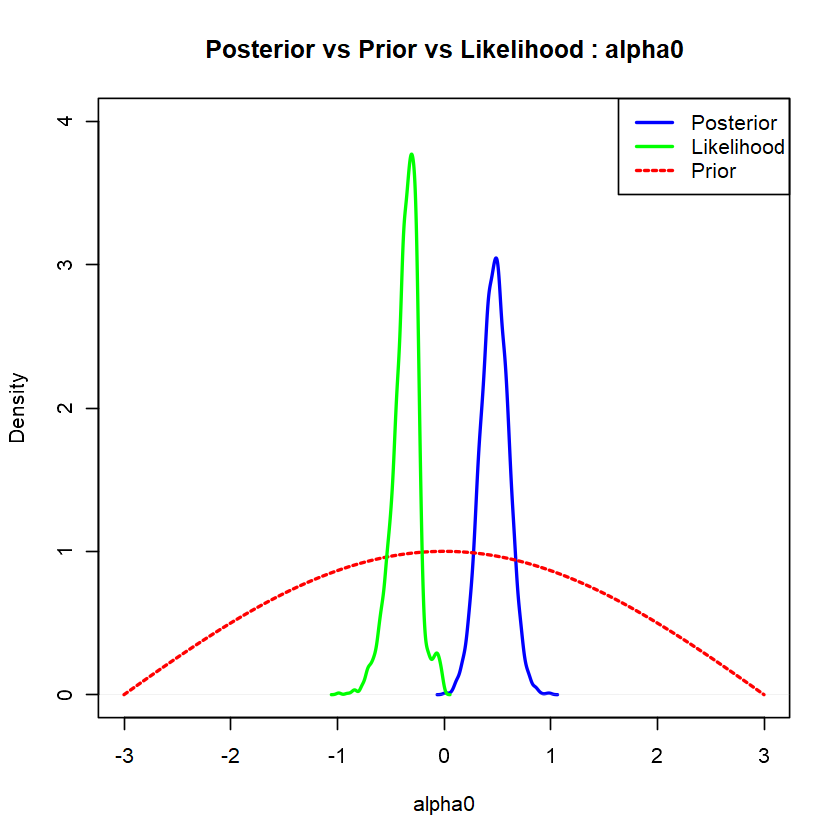

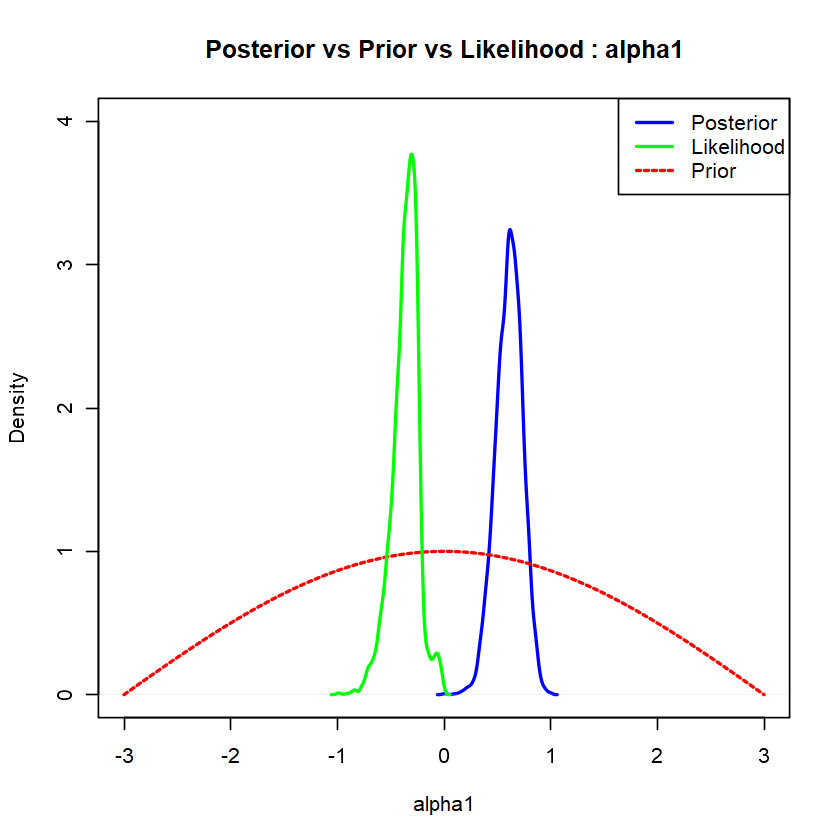

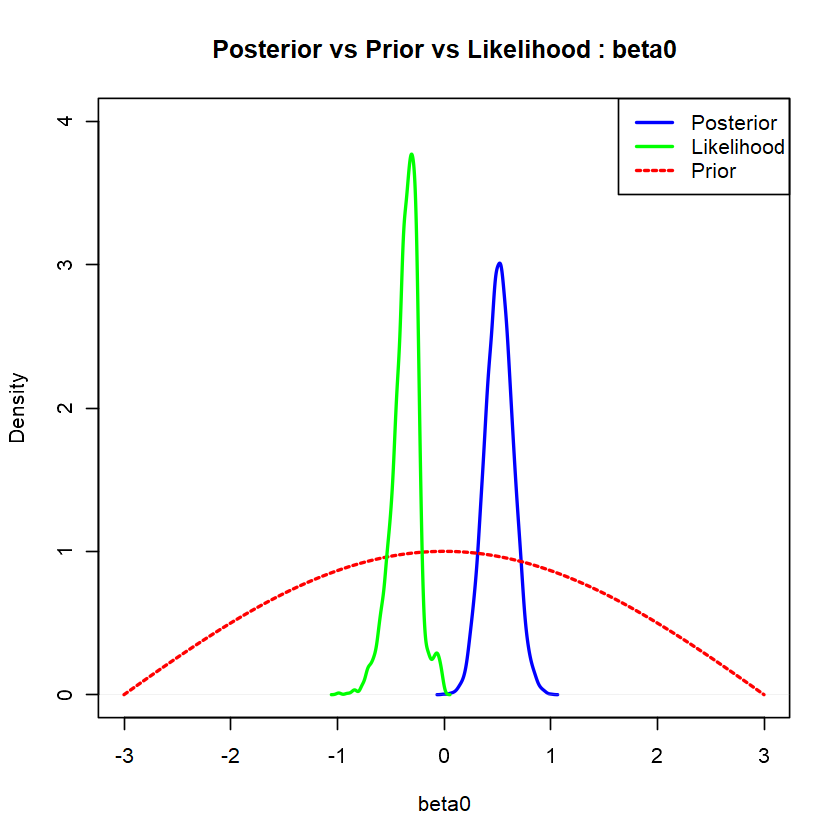

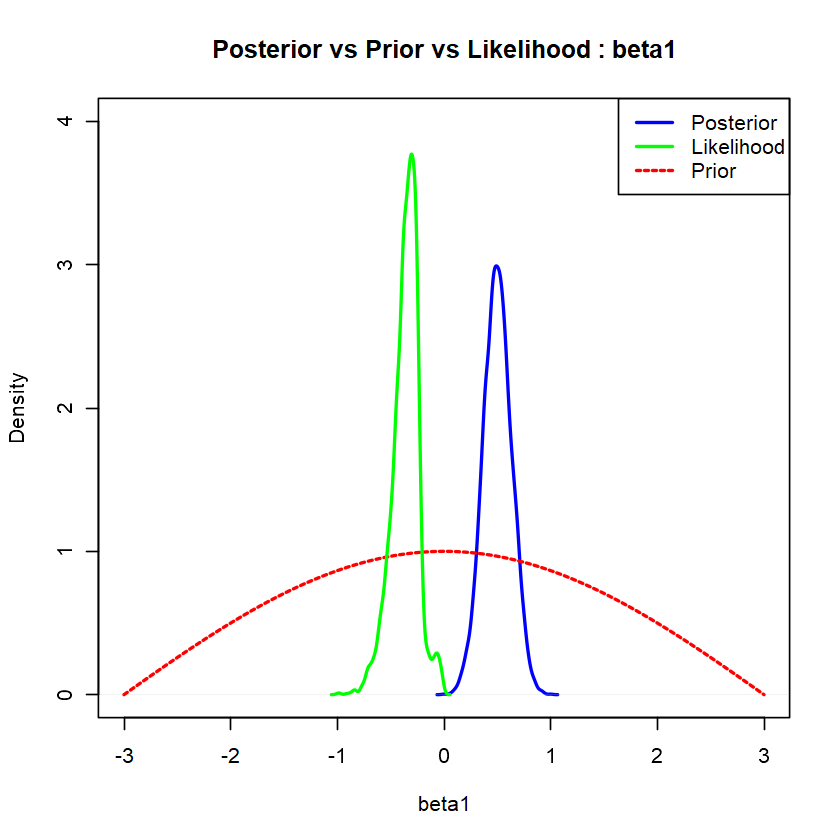

In [ ]:
bmod_zinb$graphs(sample=apply(as.matrix(samp_zinb), 2, function(x) {
  (x - min(x)) / (max(x) - min(x))
}),
                type_of_graph = "comparison",
                likelihood=(lik_zinb-max(lik_zinb))/(max(lik_zinb)-min(lik_zinb)),
                ylim=c(0,4),
                apriori=list(c("alpha0",function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("alpha1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("beta0",function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("beta1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10))))
                        )
                        )


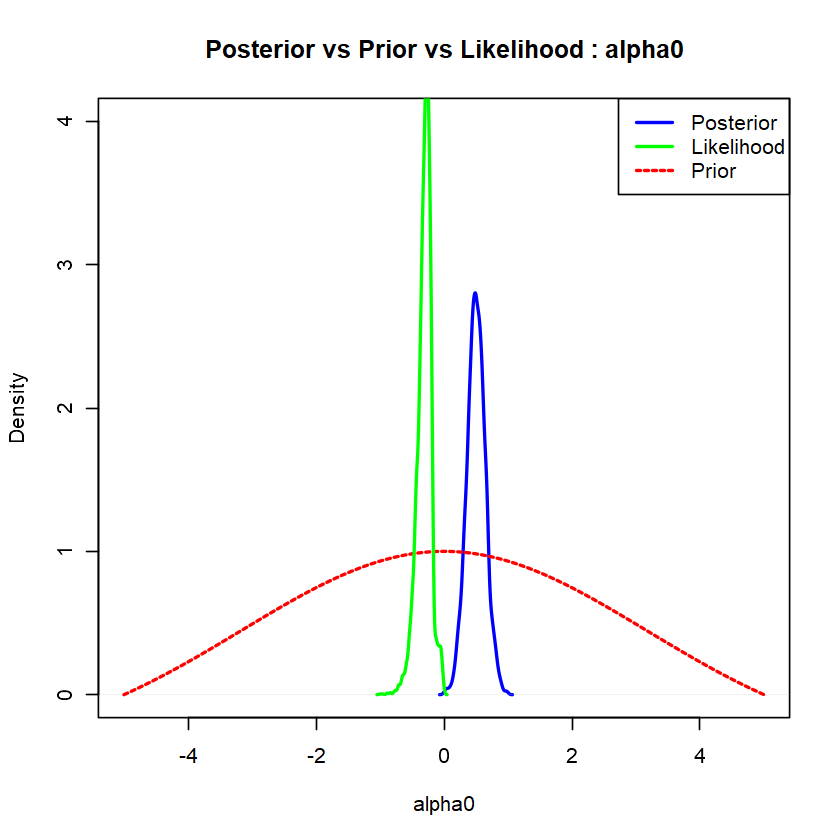

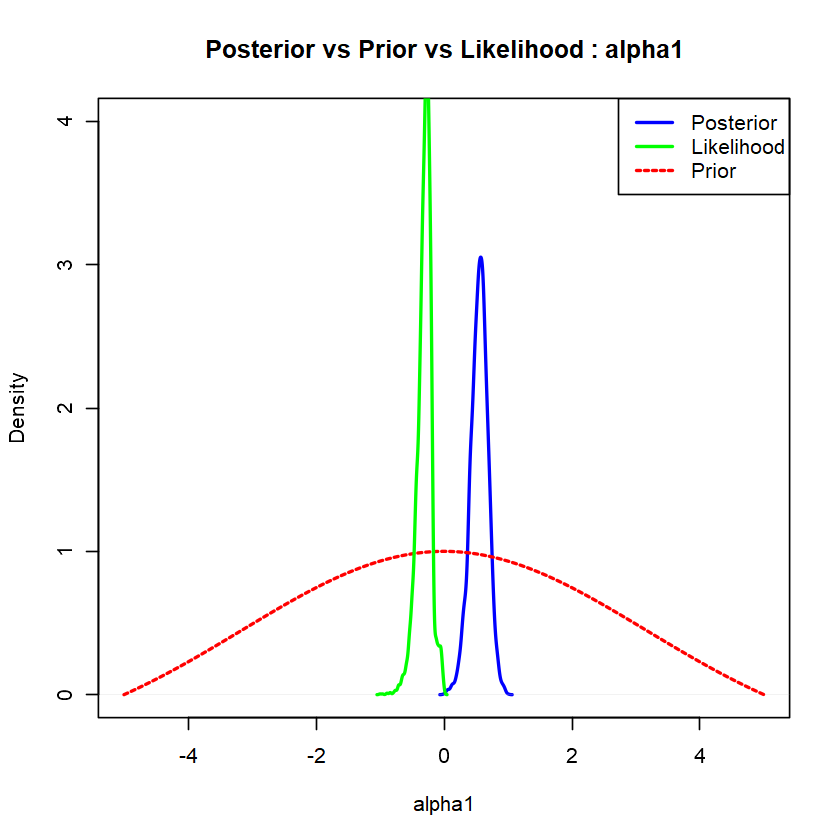

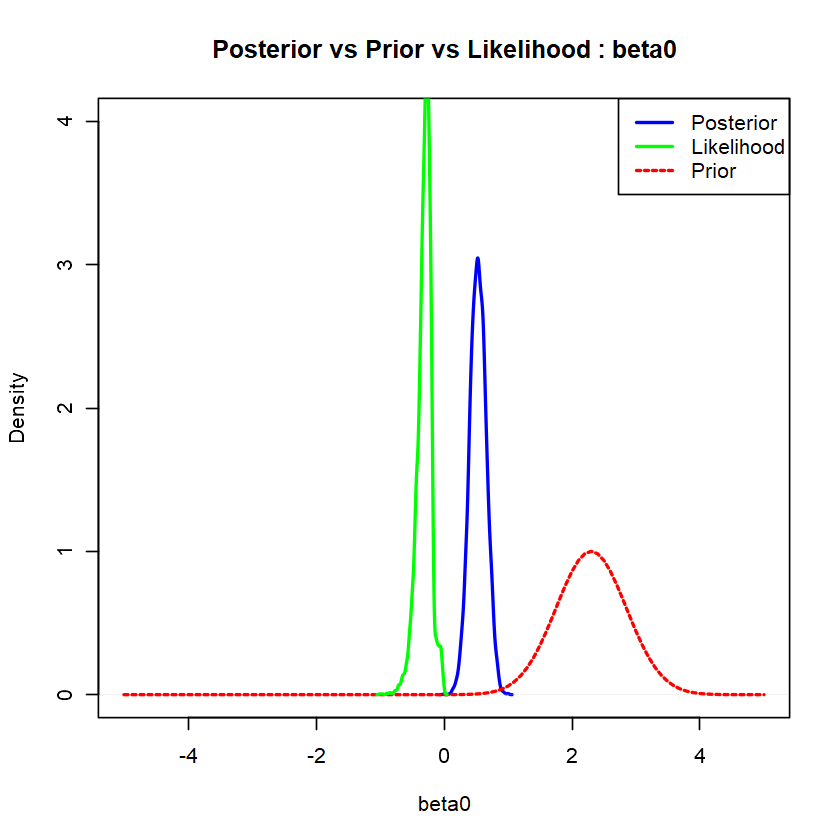

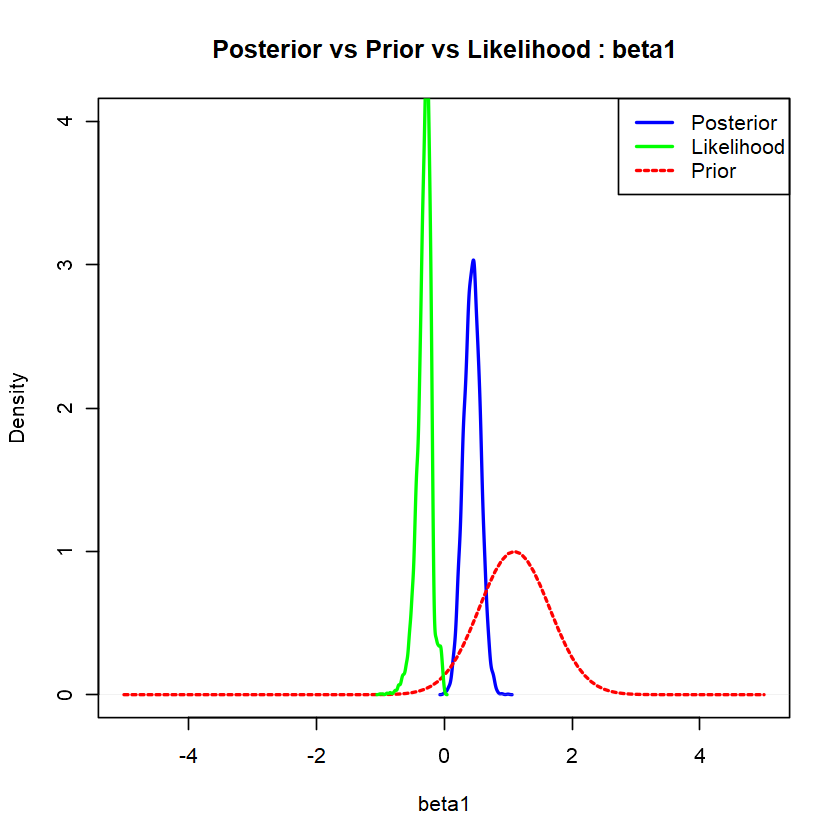

In [ ]:
bmod_zinb_op$graphs(sample=apply(as.matrix(samp_zinb_op), 2, function(x) {
  (x - min(x)) / (max(x) - min(x))
}),
                type_of_graph = "comparison",
                likelihood=(lik_zinb_op-max(lik_zinb_op))/(max(lik_zinb_op)-min(lik_zinb_op)),
                ylim=c(0,4),
                xlim=c(-5,5),
                apriori=list(c("alpha0",function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("alpha1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("beta0",function(x) scale_minmax(dnorm(x, mean = 2.3, sd = sqrt(0.3)))),
                             c("beta1", function(x) scale_minmax(dnorm(x, mean = 1.1, sd = sqrt(0.3))))
                        )
                        )



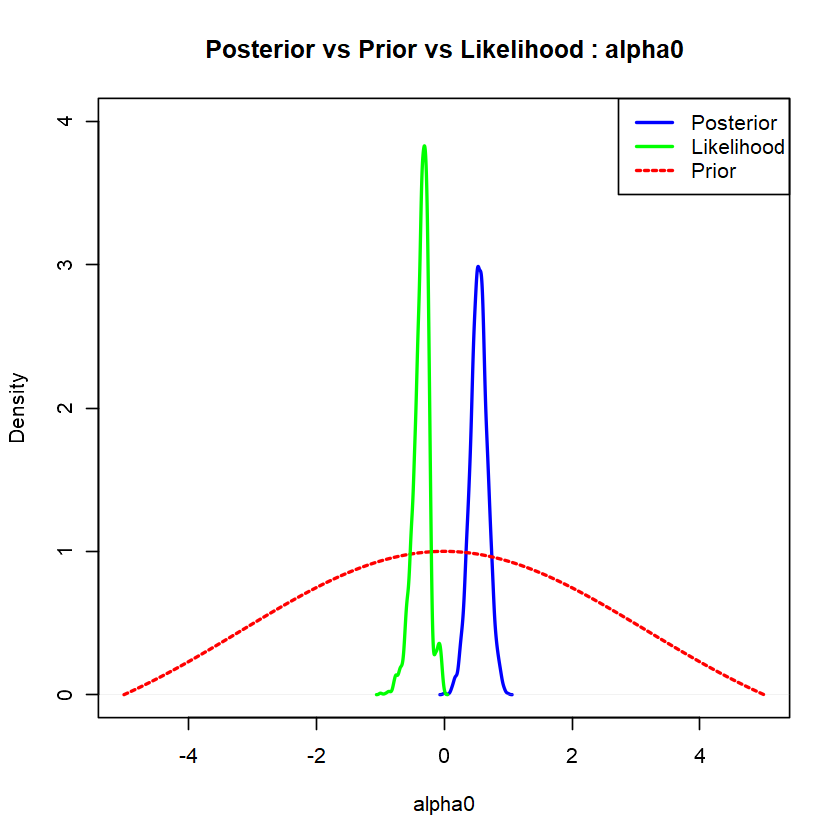

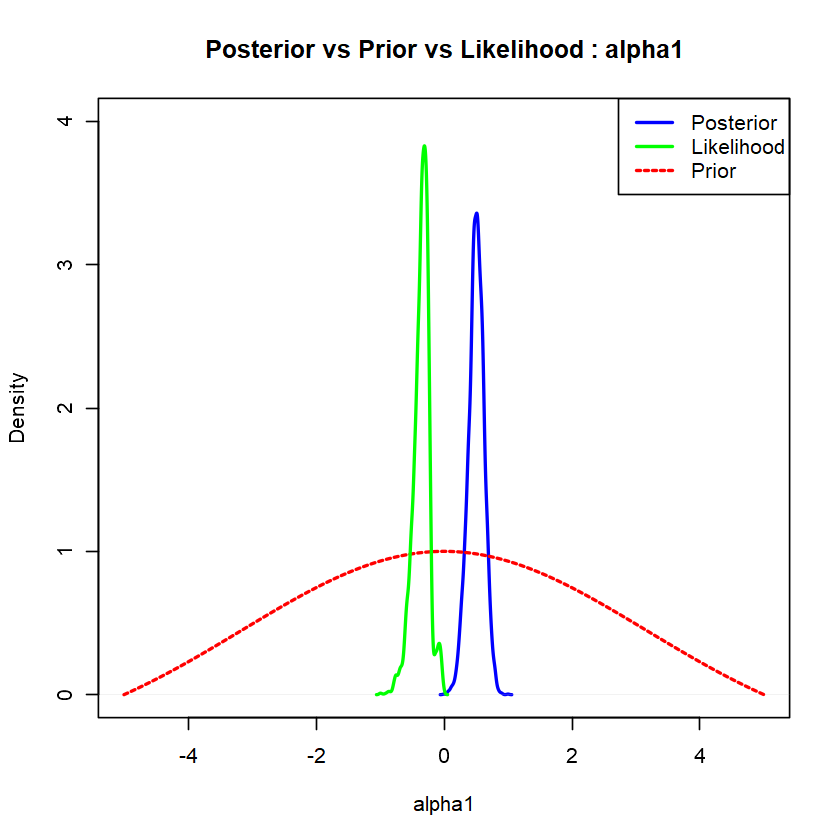

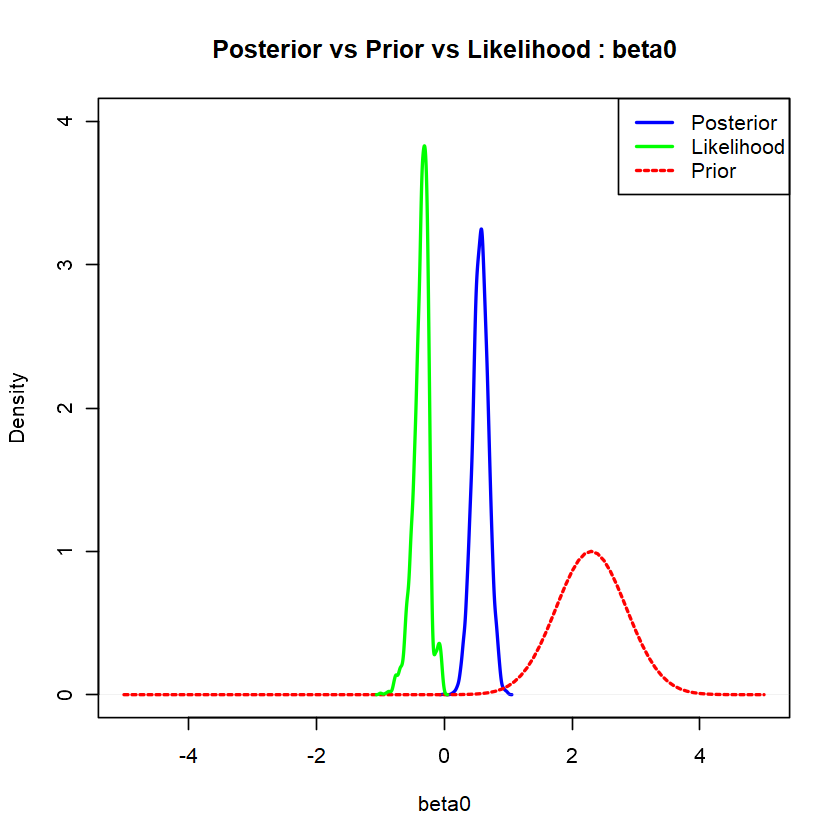

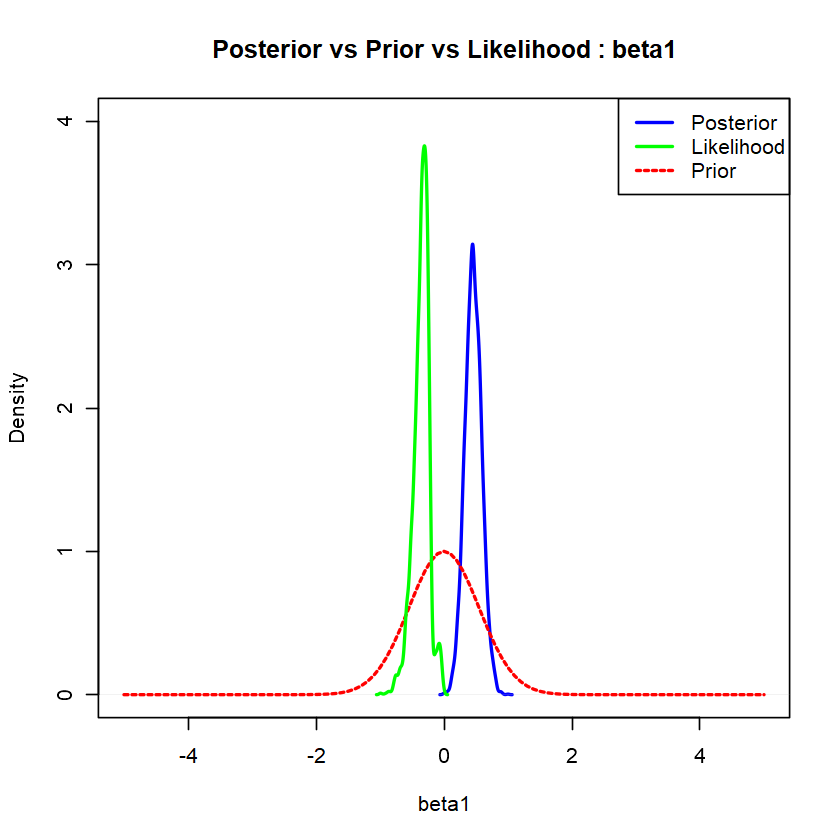

In [ ]:
bmod_zinb_pess$graphs(sample=apply(as.matrix(samp_zinb_pess), 2, function(x) {
  (x - min(x)) / (max(x) - min(x))
}),
                type_of_graph = "comparison",
                likelihood=(lik_zinb_pess-max(lik_zinb_pess))/(max(lik_zinb_pess)-min(lik_zinb_pess)),
                ylim=c(0,4),
                xlim=c(-5,5),
                apriori=list(c("alpha0",function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("alpha1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(10)))),
                             c("beta0",function(x) scale_minmax(dnorm(x, mean = 2.3, sd = sqrt(0.3)))),
                             c("beta1", function(x) scale_minmax(dnorm(x, mean = 0, sd = sqrt(0.3))))
                        )
                        )


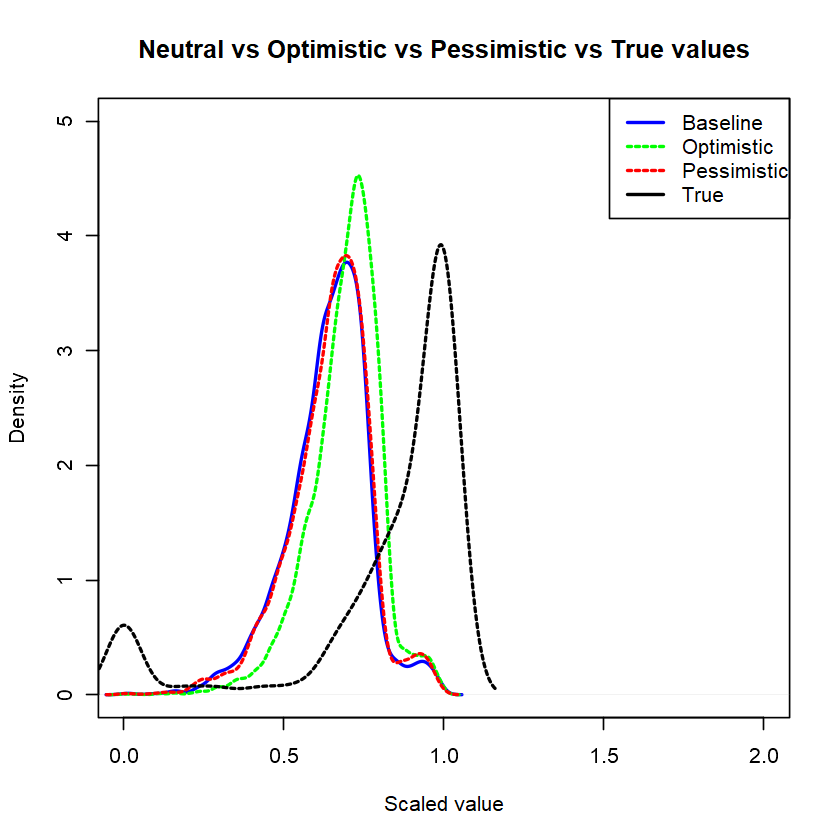

In [ ]:
# Convert to numeric vectors
lik_base <- as.numeric(lik_zinb)
lik_op   <- as.numeric(lik_zinb_op)
lik_pess <- as.numeric(lik_zinb_pess)

# Min-max scale each to [0,1] for plotting

lik_base_s <- scale_minmax(lik_base)
lik_op_s   <- scale_minmax(lik_op)
lik_pess_s <- scale_minmax(lik_pess)

# Example: plot as densities
plot(density(lik_base_s), col = "blue", lwd = 2, main = "Neutral vs Optimistic vs Pessimistic vs True values", xlab = "Scaled value",xlim=c(0,2), ylim=c(0,5))
lines(density(lik_op_s), col = "green", lwd = 2, lty = 2)
lines(density(lik_pess_s), col = "red", lwd = 2, lty = 2)
lines(density(scale_minmax(na.omit(data_dint$vf_days))), col = "black", lwd = 2, lty = 2)
legend("topright", legend = c("Baseline", "Optimistic", "Pessimistic", "True"),
       col = c("blue","green","red", "black"), lwd = 2, lty = c(1,2,2))
